In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

<h2>Preparing the data</h2>

In [2]:
import kagglehub

In [3]:
path = kagglehub.dataset_download("fanbyprinciple/iot-device-identification")

In [4]:
data_train = pd.read_csv(path + "/iot_device_train.csv")
data_test = pd.read_csv(path + "/iot_device_test.csv")

In [5]:
data_all = pd.concat([data_train, data_test], axis=0, ignore_index=True)

In [6]:
data_all = data_all.sample(frac=1, random_state=42).reset_index(drop=True)

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
le = LabelEncoder()
data_all['device_category_label'] = le.fit_transform(data_all['device_category'])

In [9]:
data_all['device_category_label']

0       3
1       0
2       8
3       8
4       4
       ..
1895    2
1896    3
1897    2
1898    5
1899    2
Name: device_category_label, Length: 1900, dtype: int32

In [10]:
data_all.columns

Index(['ack', 'ack_A', 'ack_B', 'bytes', 'bytes_A', 'bytes_A_B_ratio',
       'bytes_B', 'ds_field_A', 'ds_field_B', 'duration',
       ...
       'suffix_is_com', 'suffix_is_com.sg', 'suffix_is_else',
       'suffix_is_empty_char_value', 'suffix_is_googleapis.com',
       'suffix_is_net', 'suffix_is_org', 'suffix_is_unresolved',
       'device_category', 'device_category_label'],
      dtype='object', length=299)

In [11]:
corr = data_all.drop(axis=0, columns='device_category').corr().abs()['device_category_label'].sort_values(ascending=False)

In [12]:
print(corr)

device_category_label       1.000000
reset                       0.404447
reset_A                     0.396896
ttl_B_thirdQ                0.345751
ttl_B_median                0.338601
                              ...   
suffix_is_co.il                  NaN
suffix_is_com.sg                 NaN
suffix_is_googleapis.com         NaN
suffix_is_net                    NaN
suffix_is_org                    NaN
Name: device_category_label, Length: 298, dtype: float64


In [13]:
dummies = pd.get_dummies(data_all['device_category'], dtype=int)
print(dummies)

      TV  baby_monitor  lights  motion_sensor  security_camera  \
0      0             0       0              1                0   
1      1             0       0              0                0   
2      0             0       0              0                0   
3      0             0       0              0                0   
4      0             0       0              0                1   
...   ..           ...     ...            ...              ...   
1895   0             0       1              0                0   
1896   0             0       0              1                0   
1897   0             0       1              0                0   
1898   0             0       0              0                0   
1899   0             0       1              0                0   

      smoke_detector  socket  thermostat  watch  water_sensor  
0                  0       0           0      0             0  
1                  0       0           0      0             0  
2              

In [128]:
device_categories = dummies.columns.tolist()
print(device_categories)

['TV', 'baby_monitor', 'lights', 'motion_sensor', 'security_camera', 'smoke_detector', 'socket', 'thermostat', 'watch', 'water_sensor']


In [15]:
data_X = data_all.drop(columns=['device_category', 'device_category_label'])
print(data_X)

        ack  ack_A  ack_B    bytes  bytes_A  bytes_A_B_ratio  bytes_B  \
0        48     18     30     1382      654         0.898350      728   
1         9      5      5     1213      743         1.142203      668   
2         9      5      5     1213      743         1.806874      668   
3         9      5      5     1213      743         1.806874      668   
4        12      6      6     1548      645         0.714285      903   
...     ...    ...    ...      ...      ...              ...      ...   
1895      0      0      0      240        0         0.000000      240   
1896  24718  12359  12359  1483080   741540         1.000000   741540   
1897      0      0      0      240        0         0.000000      240   
1898     14      7      7     2411     1317         1.203838     1094   
1899      0      0      0      240        0         0.000000      240   

      ds_field_A  ds_field_B    duration  ...  suffix_is_cloudfront.net  \
0              0           0      1.7060  ...   

In [129]:
corr_per_category = []
for category in device_categories:
    corr_per_category.append(pd.concat([data_X, dummies[category]], axis=1).corr().abs()[category].sort_values(ascending=False))

In [44]:
corr_per_category_top = [corr_per_category[i].head(11) for i in range(len(corr_per_category))]
# delete the first row (the category itself)
for i in range(len(corr_per_category_top)):
    corr_per_category_top[i] = corr_per_category_top[i].iloc[1:]
print(corr_per_category_top)

[ttl_B_min       0.496075
reset_B         0.370424
ttl_A_avg       0.308538
ttl_A_firstQ    0.308538
ttl_A_max       0.308538
ttl_A_median    0.308538
ttl_A_min       0.308538
ttl_A_thirdQ    0.308538
ttl_B_median    0.287217
ttl_B_firstQ    0.278231
Name: TV, dtype: float64, reset_A                  0.660903
reset                    0.565487
ttl_B_stdev              0.517958
ttl_B_max                0.482812
ttl_B_thirdQ             0.469859
ttl_B_avg                0.434098
ttl_B_firstQ             0.424674
ttl_B_median             0.421507
packet_size_B_entropy    0.404990
ttl_B_var                0.393354
Name: baby_monitor, dtype: float64, packet_inter_arrivel_min       0.581965
B_port_is_8080                 0.577076
packet_inter_arrivel_firstQ    0.575378
ttl_min                        0.574552
ttl_firstQ                     0.573342
ds_field_B                     0.572415
packet_inter_arrivel_A_min     0.561040
packet_inter_arrivel_median    0.551864
ttl_entropy                

In [ ]:
# turn corr_per_category into a dictionary
corr_per_category_top_dict = {}
for i in range(len(device_categories)):
    corr_per_category_top_dict[device_categories[i]] = corr_per_category_top[i]
print(corr_per_category_top_dict)

{'TV': ttl_B_min       0.496075
reset_B         0.370424
ttl_A_avg       0.308538
ttl_A_firstQ    0.308538
ttl_A_max       0.308538
ttl_A_median    0.308538
ttl_A_min       0.308538
ttl_A_thirdQ    0.308538
ttl_B_median    0.287217
ttl_B_firstQ    0.278231
Name: TV, dtype: float64, 'baby_monitor': reset_A                  0.660903
reset                    0.565487
ttl_B_stdev              0.517958
ttl_B_max                0.482812
ttl_B_thirdQ             0.469859
ttl_B_avg                0.434098
ttl_B_firstQ             0.424674
ttl_B_median             0.421507
packet_size_B_entropy    0.404990
ttl_B_var                0.393354
Name: baby_monitor, dtype: float64, 'lights': packet_inter_arrivel_min       0.581965
B_port_is_8080                 0.577076
packet_inter_arrivel_firstQ    0.575378
ttl_min                        0.574552
ttl_firstQ                     0.573342
ds_field_B                     0.572415
packet_inter_arrivel_A_min     0.561040
packet_inter_arrivel_median    0.55

<h2>Feature importance</h2>

In [ ]:
# Get all unique feature names across all categories
features = set()
for i in range(len(device_categories)):
    top_corr = corr_per_category_top[i]
    if device_categories[i] in top_corr.index:
        top_corr = top_corr.drop(device_categories[i])
    features.update(top_corr.index)
features = list(features)
# order elements of all_features alphabetically
features.sort()
print(features)
print(len(features))

['B_port_is_11095', 'B_port_is_8080', 'domain_is_else', 'ds_field_B', 'http_count_host', 'http_count_req_content_type', 'http_count_resp_code', 'http_count_resp_content_type', 'http_count_user_agents', 'http_has_req_content_type', 'http_has_resp_content_type', 'http_has_user_agent', 'is_http', 'packet_inter_arrivel_A_min', 'packet_inter_arrivel_B_min', 'packet_inter_arrivel_firstQ', 'packet_inter_arrivel_median', 'packet_inter_arrivel_min', 'packet_size_A_avg', 'packet_size_A_stdev', 'packet_size_A_thirdQ', 'packet_size_A_var', 'packet_size_B_avg', 'packet_size_B_entropy', 'packet_size_B_thirdQ', 'packets_A_B_ratio', 'reset', 'reset_A', 'reset_B', 'ssl_count_client_ciphersuites', 'ssl_dom_server_name_alexaRank', 'ssl_ratio_client_elliptic_curves', 'ssl_req_bytes_stdev', 'ssl_req_bytes_var', 'ttl_A_avg', 'ttl_A_firstQ', 'ttl_A_max', 'ttl_A_median', 'ttl_A_min', 'ttl_A_thirdQ', 'ttl_B_avg', 'ttl_B_firstQ', 'ttl_B_max', 'ttl_B_median', 'ttl_B_min', 'ttl_B_stdev', 'ttl_B_thirdQ', 'ttl_B_va

In [ ]:
# create a dictionary with the elements of all_features as keys that contains the number of occurrences of each element in the list corr_per_category_top
feature_prevalence = {feature: 0 for feature in features}
for i in range(len(device_categories)):
    top_corr = corr_per_category_top[i]
    if device_categories[i] in top_corr.index:
        top_corr = top_corr.drop(device_categories[i])
    for feature in top_corr.index:
        feature_prevalence[feature] += 1
print(feature_prevalence)

{'B_port_is_11095': 1, 'B_port_is_8080': 3, 'domain_is_else': 1, 'ds_field_B': 3, 'http_count_host': 1, 'http_count_req_content_type': 1, 'http_count_resp_code': 1, 'http_count_resp_content_type': 1, 'http_count_user_agents': 1, 'http_has_req_content_type': 1, 'http_has_resp_content_type': 1, 'http_has_user_agent': 1, 'is_http': 1, 'packet_inter_arrivel_A_min': 3, 'packet_inter_arrivel_B_min': 1, 'packet_inter_arrivel_firstQ': 3, 'packet_inter_arrivel_median': 3, 'packet_inter_arrivel_min': 3, 'packet_size_A_avg': 1, 'packet_size_A_stdev': 1, 'packet_size_A_thirdQ': 1, 'packet_size_A_var': 1, 'packet_size_B_avg': 1, 'packet_size_B_entropy': 1, 'packet_size_B_thirdQ': 1, 'packets_A_B_ratio': 3, 'reset': 1, 'reset_A': 1, 'reset_B': 2, 'ssl_count_client_ciphersuites': 1, 'ssl_dom_server_name_alexaRank': 1, 'ssl_ratio_client_elliptic_curves': 1, 'ssl_req_bytes_stdev': 1, 'ssl_req_bytes_var': 1, 'ttl_A_avg': 3, 'ttl_A_firstQ': 4, 'ttl_A_max': 4, 'ttl_A_median': 4, 'ttl_A_min': 4, 'ttl_A_thi

In [48]:
#print the sum of all values in the dictionary feature_prevalence
print(sum(feature_prevalence.values()))

100


In [ ]:
feature_corr_sum = {feature: 0 for feature in features}
for items in corr_per_category_top_dict.values():
    for feature in items.index:
        feature_corr_sum[feature] += items[feature]
print(feature_corr_sum)

ttl_B_min       0.496075
reset_B         0.370424
ttl_A_avg       0.308538
ttl_A_firstQ    0.308538
ttl_A_max       0.308538
ttl_A_median    0.308538
ttl_A_min       0.308538
ttl_A_thirdQ    0.308538
ttl_B_median    0.287217
ttl_B_firstQ    0.278231
Name: TV, dtype: float64
Index(['ttl_B_min', 'reset_B', 'ttl_A_avg', 'ttl_A_firstQ', 'ttl_A_max',
       'ttl_A_median', 'ttl_A_min', 'ttl_A_thirdQ', 'ttl_B_median',
       'ttl_B_firstQ'],
      dtype='object')
reset_A                  0.660903
reset                    0.565487
ttl_B_stdev              0.517958
ttl_B_max                0.482812
ttl_B_thirdQ             0.469859
ttl_B_avg                0.434098
ttl_B_firstQ             0.424674
ttl_B_median             0.421507
packet_size_B_entropy    0.404990
ttl_B_var                0.393354
Name: baby_monitor, dtype: float64
Index(['reset_A', 'reset', 'ttl_B_stdev', 'ttl_B_max', 'ttl_B_thirdQ',
       'ttl_B_avg', 'ttl_B_firstQ', 'ttl_B_median', 'packet_size_B_entropy',
       'ttl_B_v

In [56]:
feature_groups = {
    'B_port': [feature for feature in features if feature.startswith('B_port')],
    'http': [feature for feature in features if feature.startswith('http') or feature == 'is_http'],
    'packet_inter': [feature for feature in features if feature.startswith('packet_inter')],
    'packet_size': [feature for feature in features if feature.startswith('packet_size')],
    'reset': [feature for feature in features if feature.startswith('reset')],
    'ssl': [feature for feature in features if feature.startswith('ssl')],
    'ttl_A': [feature for feature in features if feature.startswith('ttl_A')],
    'ttl_B': [feature for feature in features if feature.startswith('ttl_B')],
    'ttl_others': [feature for feature in features if feature.startswith('ttl_') and not feature.startswith('ttl_A') and not feature.startswith('ttl_B')],
    'others': []
}
for feature in features:
    if feature not in feature_groups['B_port'] and feature not in feature_groups['http'] and feature not in feature_groups['packet_inter'] and feature not in feature_groups['packet_size'] and feature not in feature_groups['reset'] and feature not in feature_groups['ssl'] and feature not in feature_groups['ttl_A'] and feature not in feature_groups['ttl_B'] and feature not in feature_groups['ttl_others']:
        feature_groups['others'].append(feature)
print(feature_groups)
print(feature_groups['others'])

{'B_port': ['B_port_is_11095', 'B_port_is_8080'], 'http': ['http_count_host', 'http_count_req_content_type', 'http_count_resp_code', 'http_count_resp_content_type', 'http_count_user_agents', 'http_has_req_content_type', 'http_has_resp_content_type', 'http_has_user_agent', 'is_http'], 'packet_inter': ['packet_inter_arrivel_A_min', 'packet_inter_arrivel_B_min', 'packet_inter_arrivel_firstQ', 'packet_inter_arrivel_median', 'packet_inter_arrivel_min'], 'packet_size': ['packet_size_A_avg', 'packet_size_A_stdev', 'packet_size_A_thirdQ', 'packet_size_A_var', 'packet_size_B_avg', 'packet_size_B_entropy', 'packet_size_B_thirdQ'], 'reset': ['reset', 'reset_A', 'reset_B'], 'ssl': ['ssl_count_client_ciphersuites', 'ssl_dom_server_name_alexaRank', 'ssl_ratio_client_elliptic_curves', 'ssl_req_bytes_stdev', 'ssl_req_bytes_var'], 'ttl_A': ['ttl_A_avg', 'ttl_A_firstQ', 'ttl_A_max', 'ttl_A_median', 'ttl_A_min', 'ttl_A_thirdQ'], 'ttl_B': ['ttl_B_avg', 'ttl_B_firstQ', 'ttl_B_max', 'ttl_B_median', 'ttl_B_m

<h3>Interactive widgets to explore feature importance</h3>

In [57]:
# make a dataframe with the data in feature_prevalence and append a column with the data in feature_corr_sum
feature_analysis = pd.DataFrame.from_dict(feature_prevalence, orient='index', columns=['prevalence'])
feature_analysis.index.name = 'feature'
feature_analysis.reset_index(inplace=True)
feature_analysis['corr_sum'] = feature_analysis['feature'].map(feature_corr_sum)
feature_analysis.head()

,feature,prevalence,corr_sum
0,B_port_is_11095,1,0.687184
1,B_port_is_8080,3,1.507778
2,domain_is_else,1,0.736364
3,ds_field_B,3,1.495379
4,http_count_host,1,0.725062


In [58]:
feature_analysis['corr_avg'] = feature_analysis['corr_sum'] / feature_analysis['prevalence']

In [59]:
feature_analysis['group'] = feature_analysis['feature'].map(
    lambda x: next((group for group, features in feature_groups.items() if x in features), 'others')
)

In [60]:
feature_analysis

,feature,prevalence,corr_sum,corr_avg,group
0,B_port_is_11095,1,0.687184,0.687184,B_port
1,B_port_is_8080,3,1.507778,0.502593,B_port
2,domain_is_else,1,0.736364,0.736364,others
3,ds_field_B,3,1.495379,0.498460,others
4,http_count_host,1,0.725062,0.725062,http
5,http_count_req_content_type,1,0.725062,0.725062,http
6,http_count_resp_code,1,0.724871,0.724871,http
7,http_count_resp_content_type,1,0.724871,0.724871,http
8,http_count_user_agents,1,0.725062,0.725062,http
9,http_has_req_content_type,1,0.725062,0.725062,http


In [61]:
import plotly.express as px

In [62]:
fig_corr = px.sunburst(
    feature_analysis, 
    path=['group', 'feature'], 
    values='corr_sum',
    color='corr_avg', color_continuous_scale='Blues',
    title='Feature importance'
    )
fig_corr.show()

d:\code\cdn\venvs\venv_up_cdn_6\Lib\site-packages\seaborn\categorical.py:3399: UserWarning:

22.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

C:\Users\randr\AppData\Local\Temp\ipykernel_31364\2366027543.py:20: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



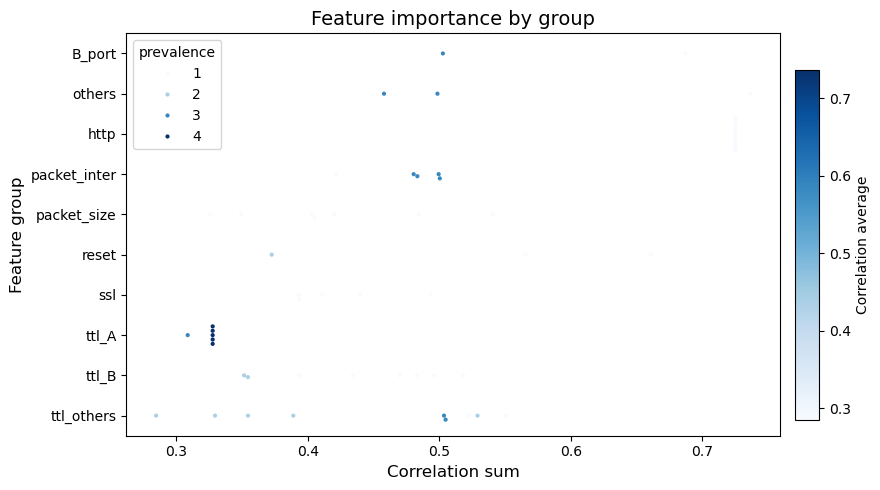

In [86]:
plt.figure(figsize=(8, 5))
ax = sns.swarmplot(
    data=feature_analysis,
    y='group',
    x='corr_avg', 
    hue='prevalence',
    size=3,  # Decrease point size
    palette='Blues'
)
ax.set_title('Feature importance by group', fontsize=14)
ax.set_xlabel('Correlation sum', fontsize=12)
ax.set_ylabel('Feature group', fontsize=12)

# Add a colorbar legend
norm = plt.Normalize(feature_analysis['corr_avg'].min(), feature_analysis['corr_avg'].max())
sm = plt.cm.ScalarMappable(cmap='Blues', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, label='Correlation average', cax=plt.gcf().add_axes([1, 0.15, 0.03, 0.7]))

plt.tight_layout()
plt.show()

<Axes: xlabel='corr_avg', ylabel='group'>

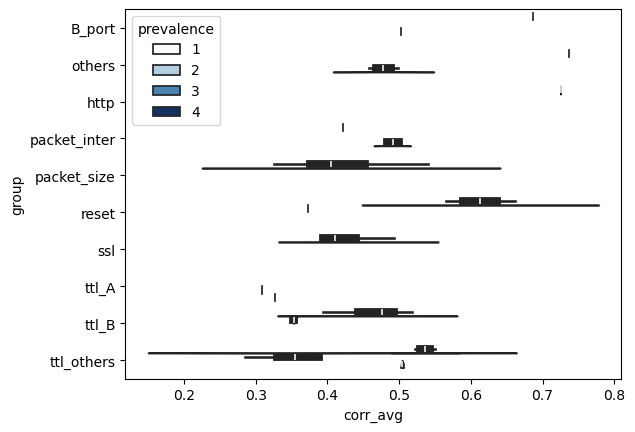

In [99]:
sns.violinplot(
    data=feature_analysis,
    x='corr_avg',
    y='group',
    hue='prevalence',
    split=True,
    palette='Blues'
)

d:\code\cdn\venvs\venv_up_cdn_6\Lib\site-packages\seaborn\categorical.py:3399: UserWarning:

80.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

d:\code\cdn\venvs\venv_up_cdn_6\Lib\site-packages\seaborn\categorical.py:3399: UserWarning:

50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

d:\code\cdn\venvs\venv_up_cdn_6\Lib\site-packages\seaborn\categorical.py:3399: UserWarning:

85.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



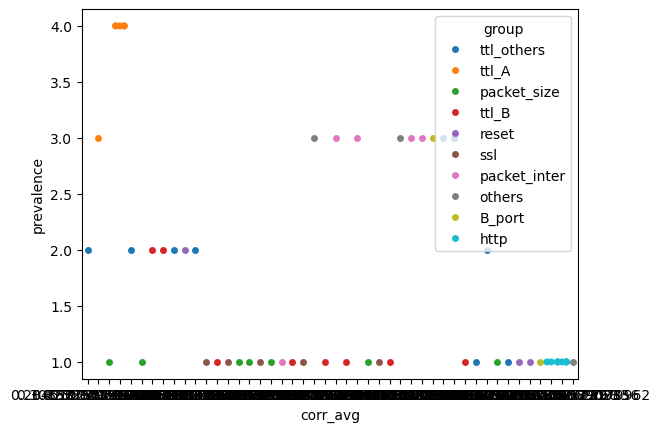

In [101]:
ax = sns.swarmplot(
    data=feature_analysis,
    x='corr_avg', y='prevalence',
    hue='group'
)

d:\code\cdn\venvs\venv_up_cdn_6\Lib\site-packages\seaborn\categorical.py:3399: UserWarning:

80.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

d:\code\cdn\venvs\venv_up_cdn_6\Lib\site-packages\seaborn\categorical.py:3399: UserWarning:

50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

d:\code\cdn\venvs\venv_up_cdn_6\Lib\site-packages\seaborn\categorical.py:3399: UserWarning:

85.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



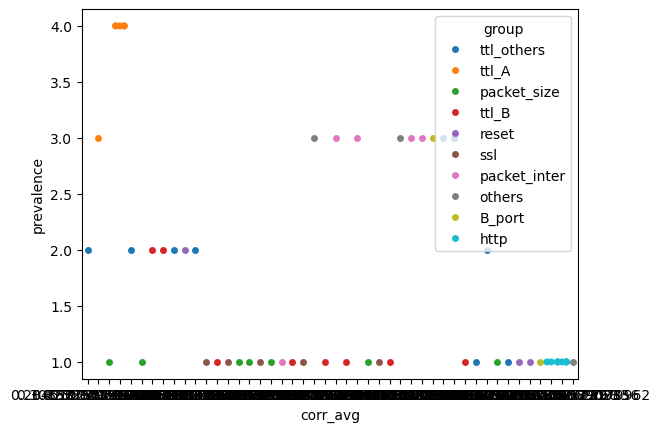

In [89]:
ax = sns.swarmplot(
    data=feature_analysis,
    x='corr_avg', y='prevalence',
    hue='group'
)

<Axes: xlabel='corr_sum', ylabel='corr_avg'>

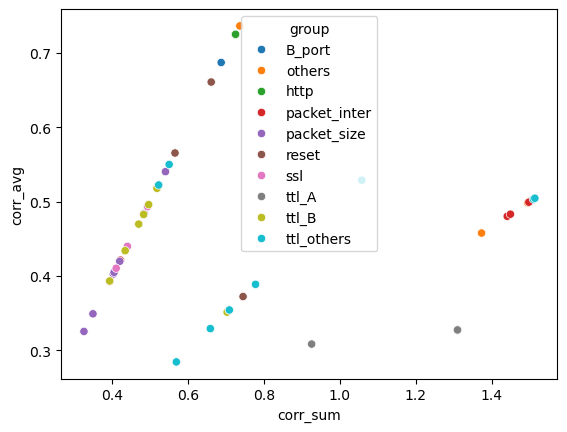

In [108]:
sns.scatterplot(
    data=feature_analysis,
    x='corr_sum', y='corr_avg',
    hue='group'
)

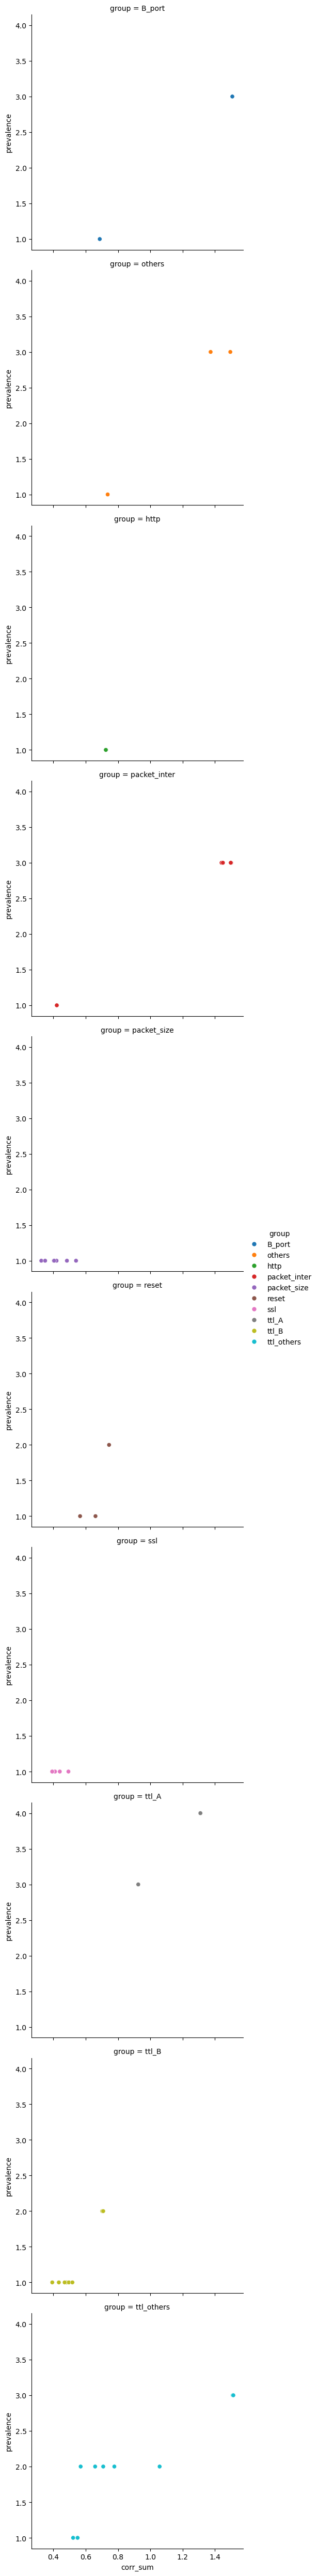

In [111]:
sns.relplot(
    data=feature_analysis,
    x='corr_sum', y='prevalence',
    hue='group',
    kind='scatter',
    row='group',
)

<h2>Feature importance per group</h2>

In [90]:
# appearance of elements of the group in important features for a device category
feature_group_prevalence = {
    group: sum(feature_prevalence[feature] for feature in features)
    for group, features in feature_groups.items()
}
print(feature_group_prevalence)

{'B_port': 4, 'http': 9, 'packet_inter': 13, 'packet_size': 7, 'reset': 4, 'ssl': 5, 'ttl_A': 23, 'ttl_B': 10, 'ttl_others': 18, 'others': 7}


In [91]:
# sum of the correlation of the elements of the group with a device category
feature_group_corr_sum = {
    group: sum(
        feature_corr_sum[feature]
        for feature in features
    )
    for group, features in feature_groups.items()
}
print(feature_group_corr_sum)

{'B_port': 2.194962497960564, 'http': 6.525172479614946, 'packet_inter': 6.311028666029685, 'packet_size': 2.9269710925138575, 'reset': 1.971245829873383, 'ssl': 2.130274439115161, 'ttl_A': 7.476210832717202, 'ttl_B': 4.205785058746653, 'ttl_others': 7.868812572798715, 'others': 3.6052182551899494}


In [92]:
# average prevalence of the elements of the group
feature_group_prevalence_density = {
    group: feature_group_prevalence[group] / len(features)
    for group, features in feature_groups.items()
}
print(feature_group_prevalence_density)

{'B_port': 2.0, 'http': 1.0, 'packet_inter': 2.6, 'packet_size': 1.0, 'reset': 1.3333333333333333, 'ssl': 1.0, 'ttl_A': 3.8333333333333335, 'ttl_B': 1.25, 'ttl_others': 2.0, 'others': 2.3333333333333335}


In [93]:
# average corr_sum of the elements of the group
feature_group_corr_sum_density = {
    group: feature_group_corr_sum[group] / len(features)
    for group, features in feature_groups.items()
}
print(feature_group_corr_sum_density)

{'B_port': 1.097481248980282, 'http': 0.7250191644016607, 'packet_inter': 1.262205733205937, 'packet_size': 0.4181387275019796, 'reset': 0.6570819432911277, 'ssl': 0.42605488782303225, 'ttl_A': 1.2460351387862003, 'ttl_B': 0.5257231323433317, 'ttl_others': 0.8743125080887462, 'others': 1.2017394183966499}


In [94]:
# average correlation of the elements of the group in 
feature_group_corr_avg = {
    group: feature_analysis['corr_avg'][feature_analysis['group'] == group].mean()
    for group in feature_groups.keys()
}
print(feature_group_corr_avg)

{'B_port': 0.594888506638853, 'http': 0.7250191644016606, 'packet_inter': 0.476926965714609, 'packet_size': 0.4181387275019796, 'reset': 0.532939372699462, 'ssl': 0.42605488782303225, 'ttl_A': 0.32436452043527064, 'ttl_B': 0.4374962810147568, 'ttl_others': 0.44073586933971076, 'others': 0.5642161999806602}


In [114]:
featureGroup_analysis = pd.DataFrame.from_dict(feature_group_prevalence, orient='index', columns=['prevalence'])
featureGroup_analysis.index.name = 'feature_group'
featureGroup_analysis.reset_index(inplace=True)
featureGroup_analysis['corr_sum'] = featureGroup_analysis['feature_group'].map(feature_group_corr_sum)
featureGroup_analysis['prevalence_density'] = featureGroup_analysis['feature_group'].map(feature_group_prevalence_density)
featureGroup_analysis['corr_sum_density'] = featureGroup_analysis['feature_group'].map(feature_group_corr_sum_density)
featureGroup_analysis['corr_avg'] = featureGroup_analysis['feature_group'].map(feature_group_corr_avg)

print(featureGroup_analysis)

  feature_group  prevalence  corr_sum  prevalence_density  corr_sum_density  \
0        B_port           4  2.194962            2.000000          1.097481   
1          http           9  6.525172            1.000000          0.725019   
2  packet_inter          13  6.311029            2.600000          1.262206   
3   packet_size           7  2.926971            1.000000          0.418139   
4         reset           4  1.971246            1.333333          0.657082   
5           ssl           5  2.130274            1.000000          0.426055   
6         ttl_A          23  7.476211            3.833333          1.246035   
7         ttl_B          10  4.205785            1.250000          0.525723   
8    ttl_others          18  7.868813            2.000000          0.874313   
9        others           7  3.605218            2.333333          1.201739   

   corr_avg  
0  0.594889  
1  0.725019  
2  0.476927  
3  0.418139  
4  0.532939  
5  0.426055  
6  0.324365  
7  0.437496  
8  0

<h3>Correlations per device type</h3>

In [126]:
import matplotlib

In [158]:
# map cmap from 0 to 1 to the number of elements in feature_groups.keys()
cmap = matplotlib.colormaps['gist_rainbow']
cmap_feature_groups = {group: cmap(i / len(feature_groups.keys())) for i, group in enumerate(feature_groups.keys())}
cmap_features = {row[1].feature: cmap_feature_groups[row[1].group] for row in feature_analysis.iterrows()}
cmap_features_perDeviceCategory = {device_category: {feature: cmap_features[feature] for feature in corr_per_category_top_dict[device_category].keys()} for device_category in device_categories}

C:\Users\randr\AppData\Local\Temp\ipykernel_31364\1671038018.py:37: UserWarning:

The figure layout has changed to tight



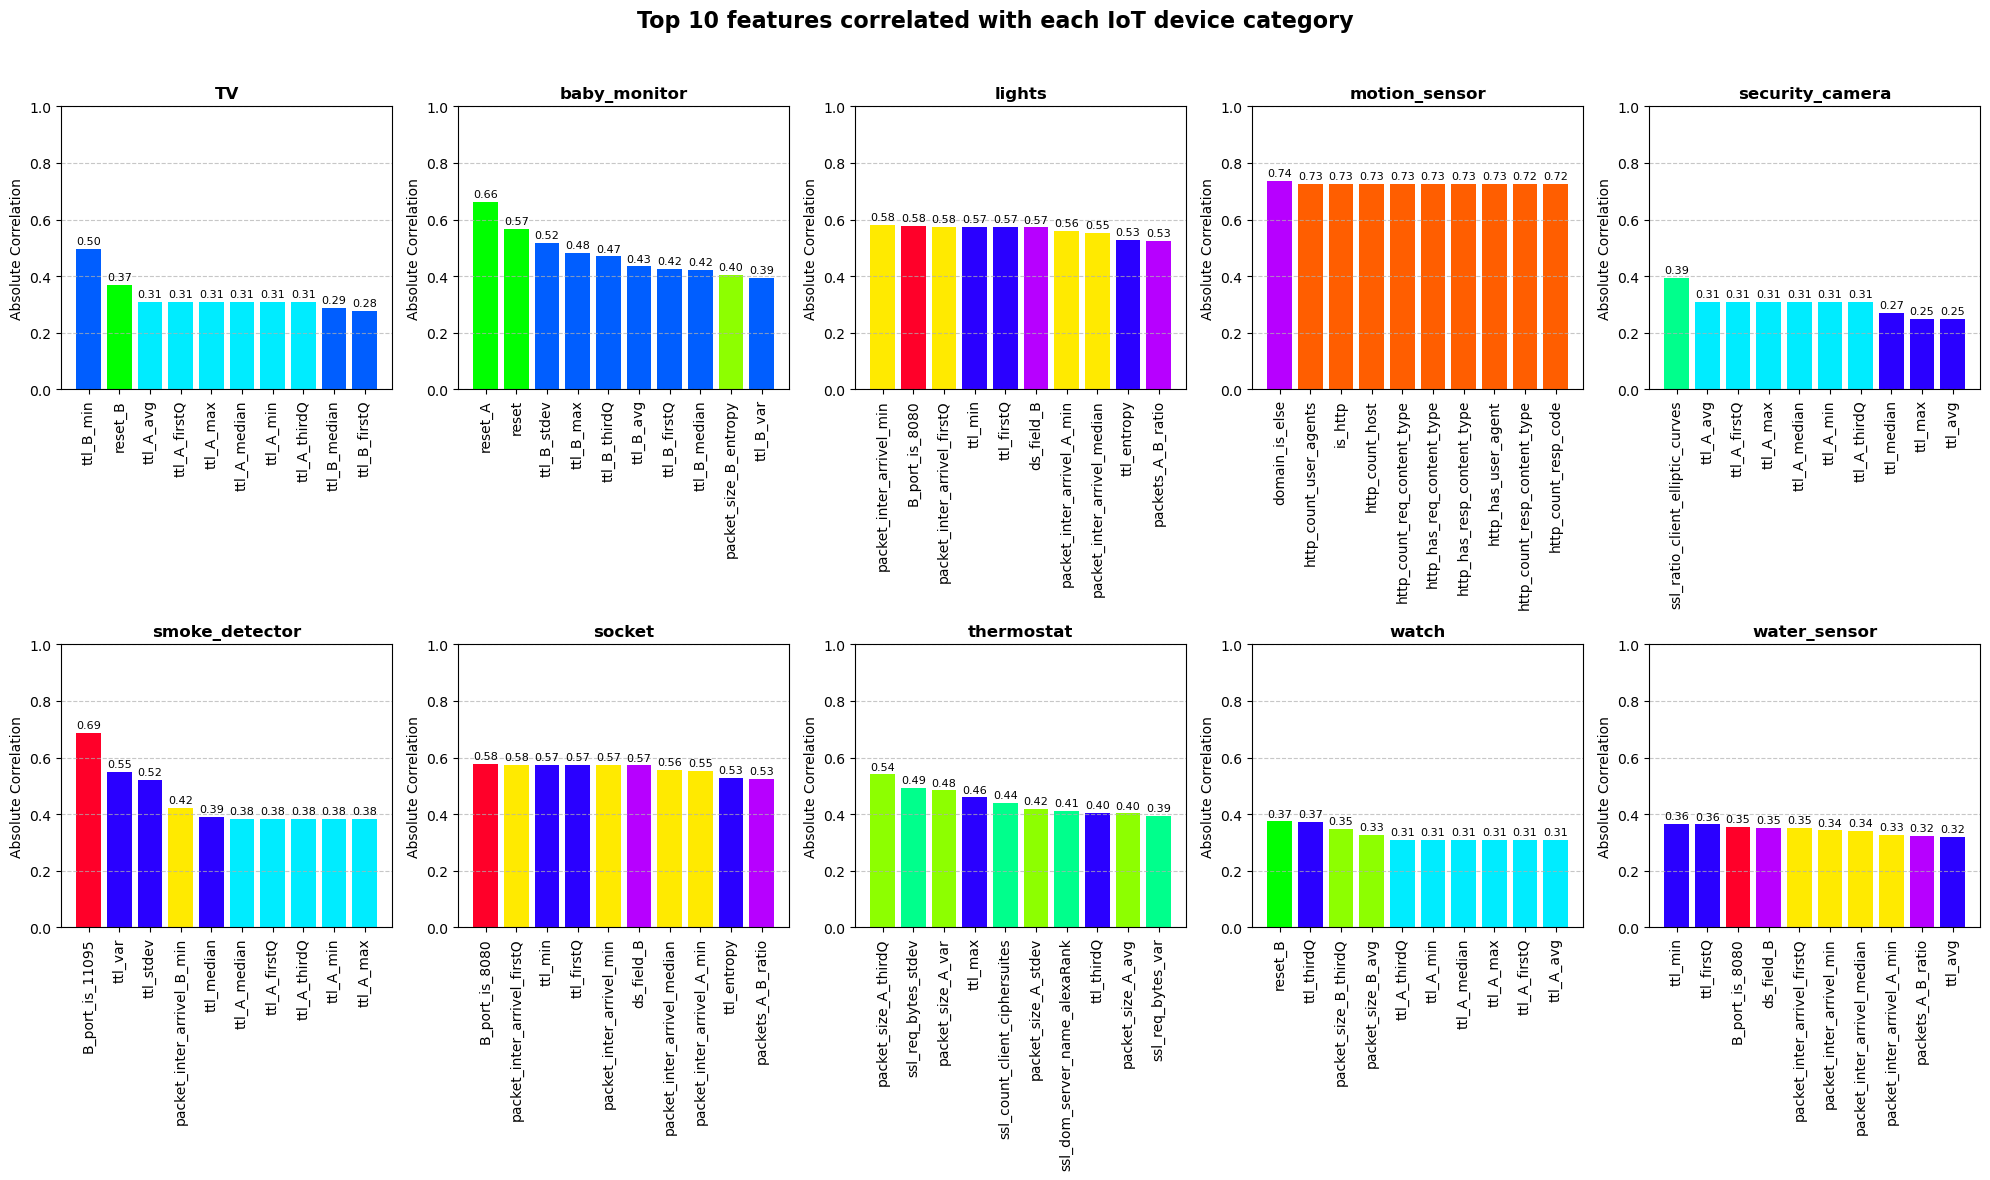

In [156]:
# Create a figure with subplots in a 2x5 grid
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 12), constrained_layout=True)
axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

# Loop through each category and create a bar plot with distinct colors
for i, category in enumerate(device_categories):
    # Get top correlations for this category
    top_corr = corr_per_category_top[i]
    
    # Create vertical bar plot with distinct colors
    ax = axes[i]
    
    # Create bars with colors corresponding to each feature
    bars = ax.bar(range(len(top_corr)), top_corr.values, color=cmap_features_perDeviceCategory[category].values())
    
    # Add x-axis labels with rotation
    ax.set_xticks(range(len(top_corr)))
    ax.set_xticklabels(top_corr.index, rotation=90)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)
    
    # Add labels and title
    ax.set_title(f'{category}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Absolute Correlation')
    
    # Set the y-axis to go from 0 to 1 (correlation range)
    ax.set_ylim(0, 1.0)
    
    # Add grid for better readability
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Top 10 features correlated with each IoT device category', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the suptitle
plt.show()

<h3>Investigating colinearity</h3>

In [ ]:
feature_correlations=data_X.corr().abs()

In [175]:
feature_correlations.head()

,ack,ack_A,ack_B,bytes,bytes_A,bytes_A_B_ratio,bytes_B,ds_field_A,ds_field_B,duration,...,suffix_is_cloudfront.net,suffix_is_co.il,suffix_is_com,suffix_is_com.sg,suffix_is_else,suffix_is_empty_char_value,suffix_is_googleapis.com,suffix_is_net,suffix_is_org,suffix_is_unresolved
ack,1.000000,0.946281,0.994306,0.959555,0.957285,0.526763,0.963758,NaN,0.030697,0.292857,...,NaN,NaN,0.006919,NaN,0.005326,0.018417,NaN,NaN,NaN,0.009491
ack_A,0.946281,1.000000,0.906437,0.817174,0.812549,0.464372,0.989527,NaN,0.043373,0.581142,...,NaN,NaN,0.009633,NaN,0.032888,0.052808,NaN,NaN,NaN,0.013192
ack_B,0.994306,0.906437,1.000000,0.984026,0.982586,0.535000,0.932713,NaN,0.025856,0.190998,...,NaN,NaN,0.005872,NaN,0.003953,0.006589,NaN,NaN,NaN,0.008069
bytes,0.959555,0.817174,0.984026,1.000000,0.999966,0.545585,0.858196,NaN,0.018226,0.015180,...,NaN,NaN,0.004224,NaN,0.017874,0.010977,NaN,NaN,NaN,0.006450
bytes_A,0.957285,0.812549,0.982586,0.999966,1.000000,0.545185,0.853963,NaN,0.017547,0.007351,...,NaN,NaN,0.004091,NaN,0.018896,0.012342,NaN,NaN,NaN,0.006232


In [187]:
all_features = feature_correlations.columns.to_list()

In [232]:
print(all_features)

['B_is_dynamic_and_or_private_port', 'B_is_system_port', 'B_is_user_port', 'B_port_is_11095', 'B_port_is_1900', 'B_port_is_5222', 'B_port_is_5223', 'B_port_is_5228', 'B_port_is_54975', 'B_port_is_80', 'B_port_is_8080', 'B_port_is_8280', 'B_port_is_9543', 'B_port_is_else', 'ack', 'ack_A', 'ack_B', 'bytes', 'bytes_A', 'bytes_A_B_ratio', 'bytes_B', 'domain_is_dlink', 'domain_is_else', 'domain_is_epicurious', 'domain_is_google', 'domain_is_hp', 'domain_is_hpeprint', 'domain_is_livecdn', 'domain_is_mako', 'domain_is_proteussensor', 'domain_is_samsung', 'domain_is_unresolved', 'ds_field_A', 'ds_field_B', 'duration', 'http_GET', 'http_POST', 'http_bytes_avg', 'http_bytes_entropy', 'http_bytes_firstQ', 'http_bytes_max', 'http_bytes_median', 'http_bytes_min', 'http_bytes_stdev', 'http_bytes_sum', 'http_bytes_thirdQ', 'http_bytes_var', 'http_cookie_count', 'http_cookie_values_avg', 'http_cookie_values_entropy', 'http_cookie_values_firstQ', 'http_cookie_values_max', 'http_cookie_values_median', '

In [283]:
all_features_groups = {
    'B_port': [feature for feature in all_features if feature.startswith('B_port') or ('B' in feature and 'port' in feature)],
    'domain': [feature for feature in all_features if feature.startswith('domain_')],
    'http_bytes': [feature for feature in all_features if feature.startswith('http_bytes_')],
    'http_cookie': [feature for feature in all_features if feature.startswith('http_cookie_')],
    'http_count': [feature for feature in all_features if feature.startswith('http_count_')],
    'http_inter': [feature for feature in all_features if feature.startswith('http_inter_')],
    'http_req': [feature for feature in all_features if feature.startswith('http_req_')],
    'http_resp': [feature for feature in all_features if feature.startswith('http_resp_')],
    'http_time': [feature for feature in all_features if feature.startswith('http_time_')],
    'http_type': [feature for feature in all_features if (('http' in feature) and feature.startswith('is_'))],
    'http_other': [],
    'num_packets': [feature for feature in all_features if feature.startswith('packets')],
    'packet_inter_arrivel_A': [feature for feature in all_features if feature.startswith('packet_inter_arrivel_A_')],
    'packet_inter_arrivel_B': [feature for feature in all_features if feature.startswith('packet_inter_arrivel_B_')],
    'packet_inter_arrivel_other': [feature for feature in all_features if feature.startswith('packet_inter_arrivel_') and not feature.startswith('packet_inter_arrivel_A_') and not feature.startswith('packet_inter_arrivel_B_')],
    'packet_size': [feature for feature in all_features if feature.startswith('packet_size_')],
    'ssl_count': [feature for feature in all_features if feature.startswith('ssl_count_')],
    'ssl_handshake': [feature for feature in all_features if feature.startswith('ssl_handshake_')],
    'ssl_req': [feature for feature in all_features if feature.startswith('ssl_req_')],
    'ssl_resp': [feature for feature in all_features if feature.startswith('ssl_resp_')],
    'subdomain': [feature for feature in all_features if feature.startswith('subdomain_')],
    'suffix': [feature for feature in all_features if feature.startswith('suffix_')],
    'tcp_analysis': [feature for feature in all_features if feature.startswith('tcp_analysis_')],
    'ttl_A': [feature for feature in all_features if feature.startswith('ttl_A_')],
    'ttl_B': [feature for feature in all_features if feature.startswith('ttl_B_')],
    'ttl_other': [feature for feature in all_features if feature.startswith('ttl_') and not feature.startswith('ttl_A_') and not feature.startswith('ttl_B_')],
    'other': []
}
for feature in all_features:
    if (
        feature.startswith('http_') 
        and (not feature in all_features_groups['http_bytes'])
        and (not feature in all_features_groups['http_cookie'])
        and (not feature in all_features_groups['http_count'])
        and (not feature in all_features_groups['http_inter'])
        and (not feature in all_features_groups['http_req'])
        and (not feature in all_features_groups['http_resp'])
        and (not feature in all_features_groups['http_time'])
        and (not feature in all_features_groups['http_type'])
    ): 
        all_features_groups['http_other'].append(feature)
features_not_in_others = []
for key, value in all_features_groups.items():
    features_not_in_others.extend(value)
for feature in all_features:
    if feature not in features_not_in_others:
        all_features_groups['other'].append(feature)
print(all_features_groups)

{'B_port': ['B_is_dynamic_and_or_private_port', 'B_is_system_port', 'B_is_user_port', 'B_port_is_11095', 'B_port_is_1900', 'B_port_is_5222', 'B_port_is_5223', 'B_port_is_5228', 'B_port_is_54975', 'B_port_is_80', 'B_port_is_8080', 'B_port_is_8280', 'B_port_is_9543', 'B_port_is_else'], 'domain': ['domain_is_dlink', 'domain_is_else', 'domain_is_epicurious', 'domain_is_google', 'domain_is_hp', 'domain_is_hpeprint', 'domain_is_livecdn', 'domain_is_mako', 'domain_is_proteussensor', 'domain_is_samsung', 'domain_is_unresolved'], 'http_bytes': ['http_bytes_avg', 'http_bytes_entropy', 'http_bytes_firstQ', 'http_bytes_max', 'http_bytes_median', 'http_bytes_min', 'http_bytes_stdev', 'http_bytes_sum', 'http_bytes_thirdQ', 'http_bytes_var'], 'http_cookie': ['http_cookie_count', 'http_cookie_values_avg', 'http_cookie_values_entropy', 'http_cookie_values_firstQ', 'http_cookie_values_max', 'http_cookie_values_median', 'http_cookie_values_min', 'http_cookie_values_stdev', 'http_cookie_values_sum', 'http

In [284]:
feature_correlations_per_group = {
    key: pd.DataFrame() for key in all_features_groups.keys()
}

In [ ]:
for key in feature_correlations_per_group.keys():
    tempdf_lowColinearity = pd.DataFrame(index=all_features_groups[key], columns=all_features_groups[key])
    for row in feature_correlations.iterrows():
        if row[0] in all_features_groups[key]:
            tempdf_lowColinearity[row[0]] = tempdf_lowColinearity.index.map(lambda x: feature_correlations.loc[x, row[0]])
    feature_correlations_per_group[key] = tempdf_lowColinearity.dropna(axis=0, how='all').dropna(axis=1, how='all')
print(feature_correlations_per_group)

{'B_port':                                   B_is_dynamic_and_or_private_port  \
B_is_dynamic_and_or_private_port                          1.000000   
B_is_system_port                                          0.035773   
B_is_user_port                                            0.029394   
B_port_is_11095                                           0.007651   
B_port_is_1900                                            0.002111   
B_port_is_5228                                            0.002588   
B_port_is_80                                              0.010209   
B_port_is_8080                                            0.019294   
B_port_is_else                                            0.056783   

                                  B_is_system_port  B_is_user_port  \
B_is_dynamic_and_or_private_port          0.035773        0.029394   
B_is_system_port                          1.000000        0.997877   
B_is_user_port                            0.997877        1.000000   
B_port_i

In [308]:
feature_group_names = {
    'B_port': 'B packets destination port',
    'domain': 'Common domains',
    'http_bytes': 'HTTP bytes',
    'http_cookie': 'HTTP cookie',
    'http_count': 'HTTP count',
    'http_inter': 'Time between HTTP requests',
    'http_req': 'Number of bytes of HTTP requests',
    'http_resp': 'Number of bytes of HTTP responses',
    'http_time': 'HTTP date header',
    'http_type': 'HTTP request type',
    'http_other': 'Other HTTP features',
    'num_packets': 'Number of packets',
    'packet_inter_arrivel_A': 'Time between A packets',
    'packet_inter_arrivel_B': 'Time between B packets',
    'packet_inter_arrivel_other': 'Time between other packets',
    'packet_size': 'Packet size',
    'ssl_count': 'Counts of SSL packets',
    'ssl_handshake': 'SSL handshake duration',
    'ssl_req': 'Number of bytes of SSL requests',
    'ssl_resp': 'Number of bytes of SSL responses',
    'subdomain': 'Common subdomains',
    'suffix': 'Common suffixes',
    'tcp_analysis': 'TCP connection status',
    'ttl_A': 'Time To Live of A packets',
    'ttl_B': 'Time To Live of B packets',
    'ttl_other': 'Time To Live of other packets',
    'other': 'Other features'
}

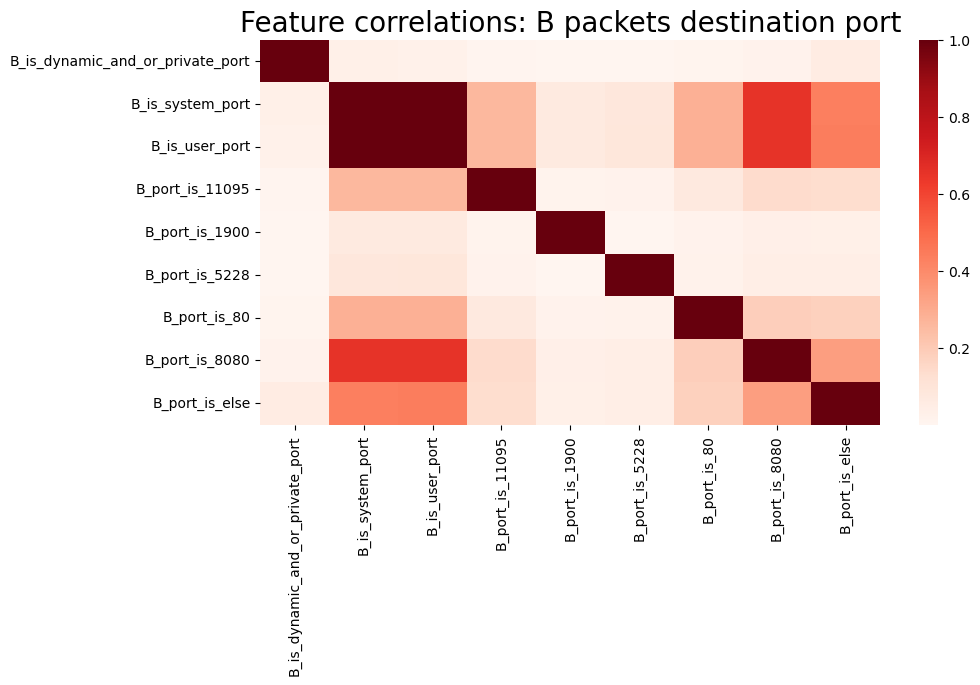

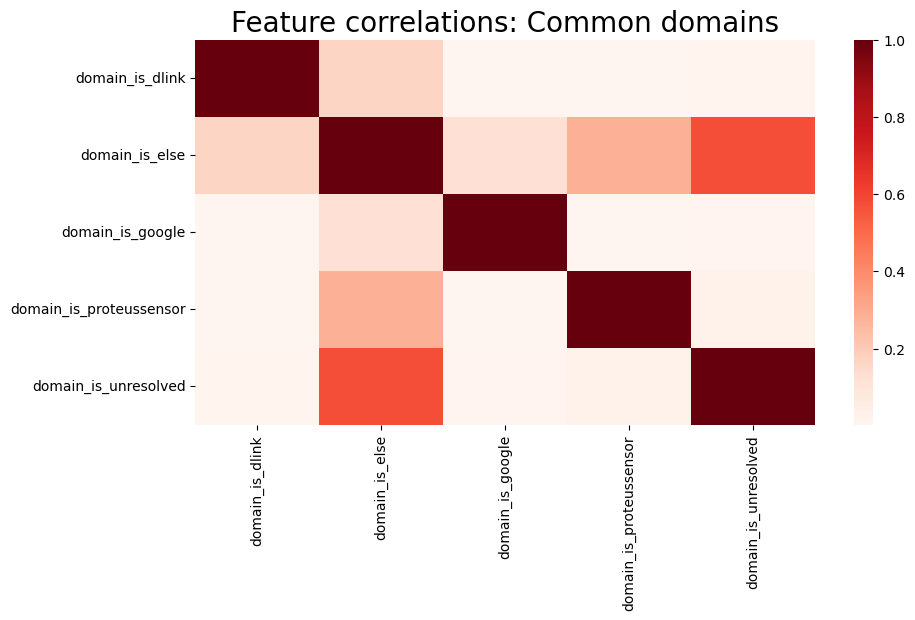

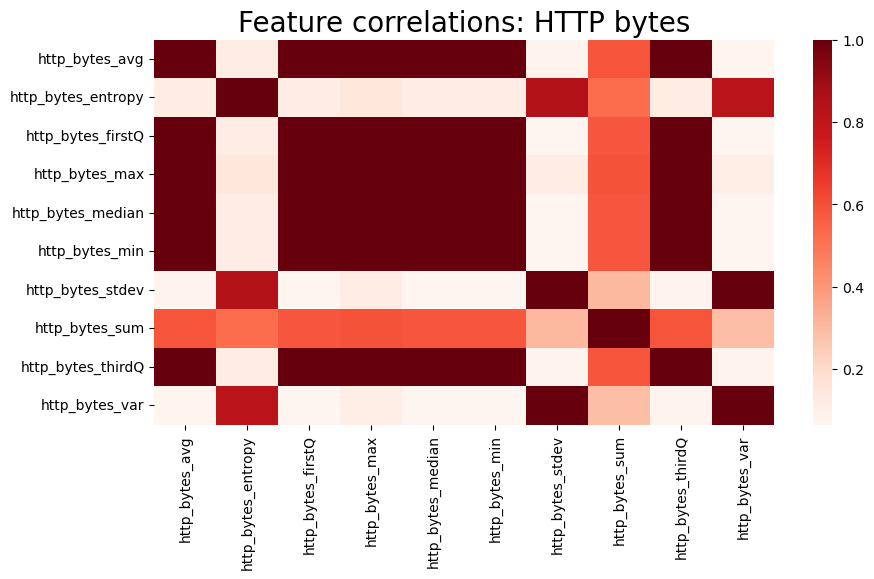

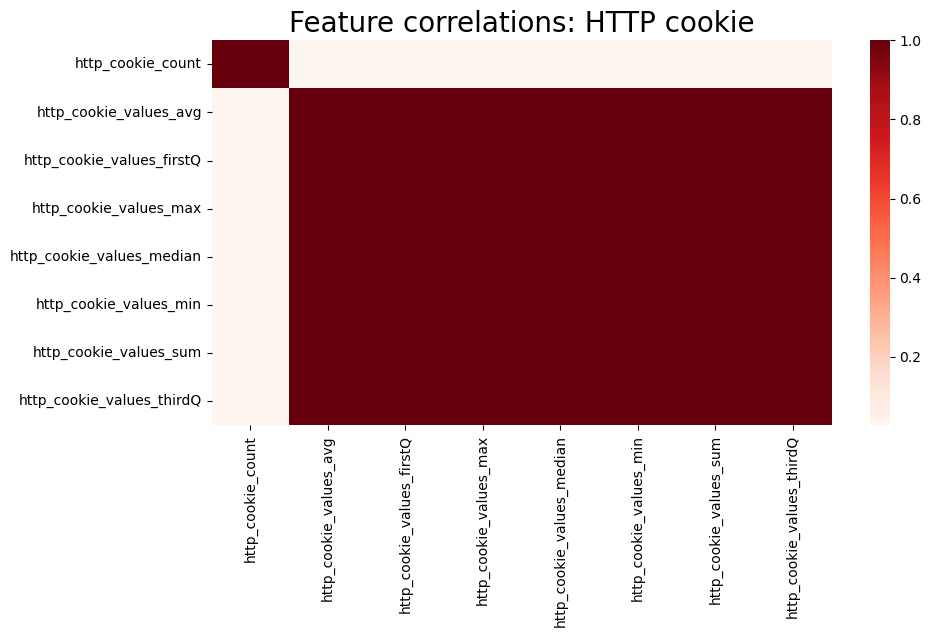

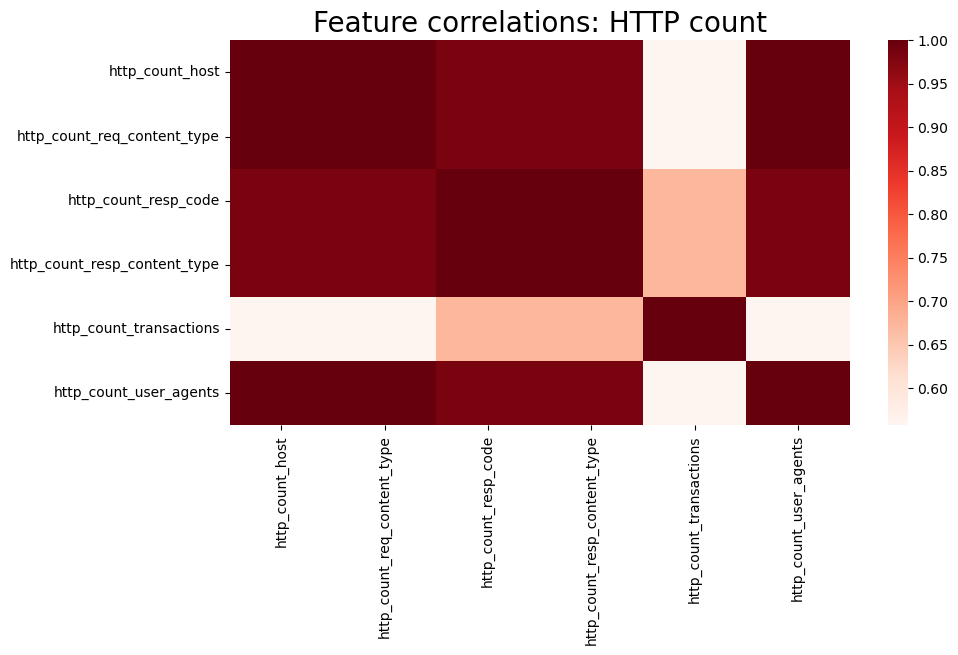

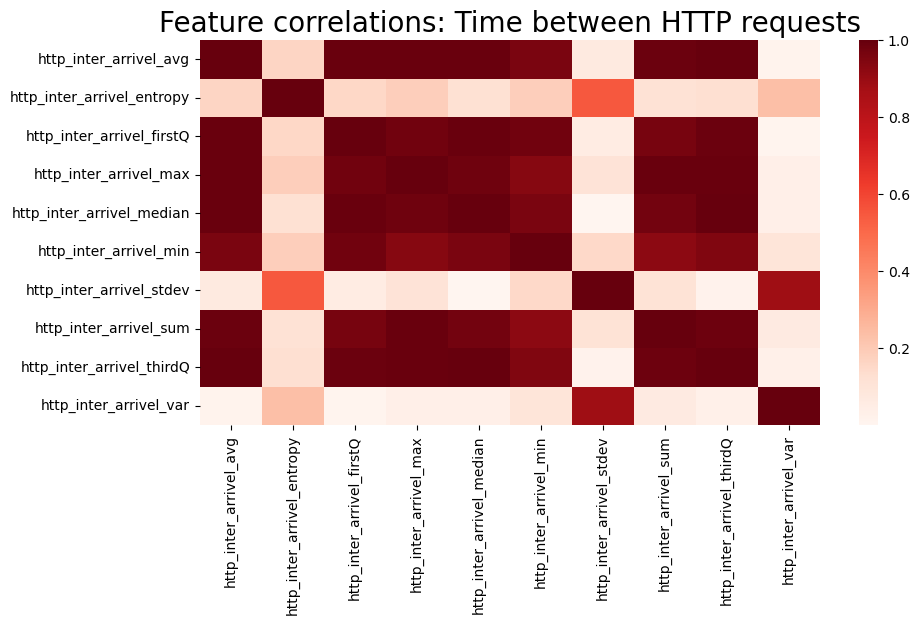

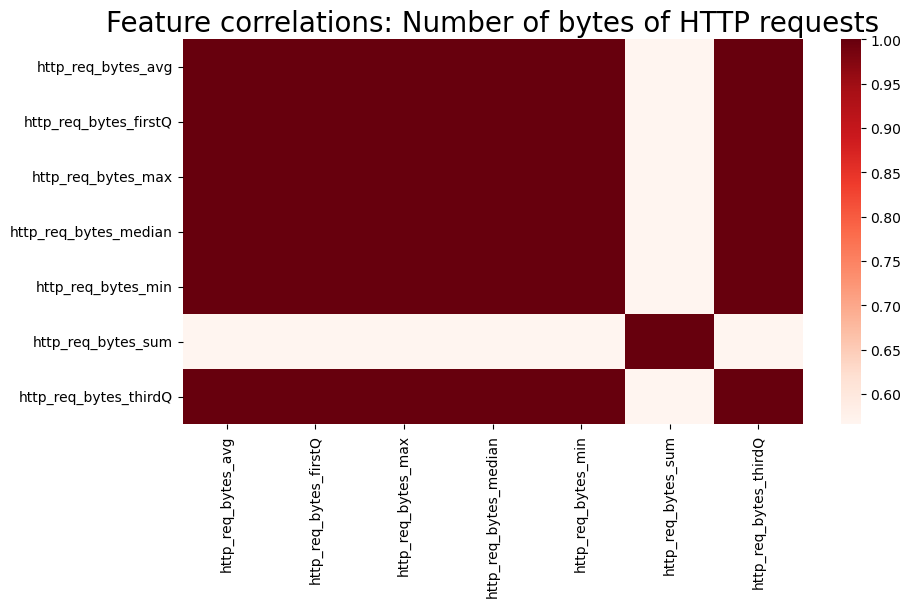

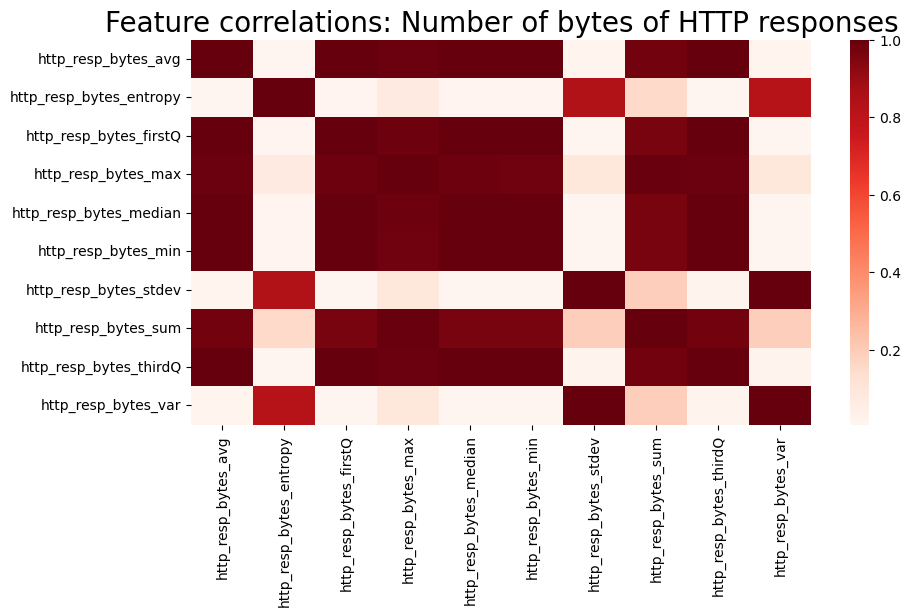

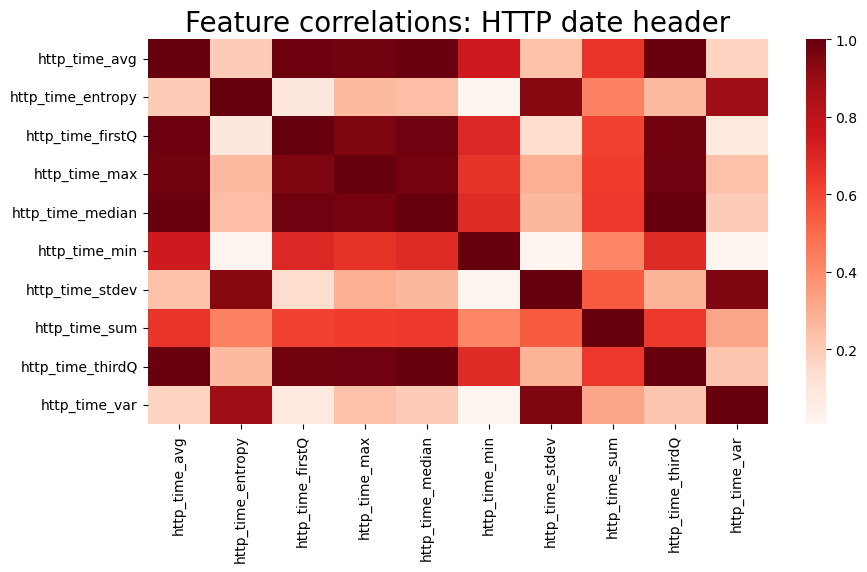

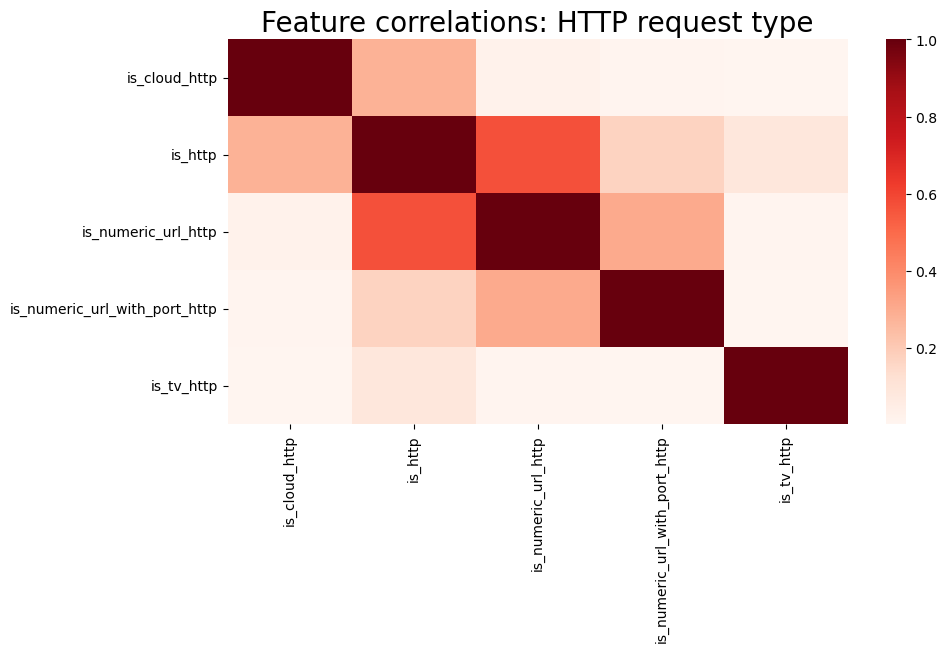

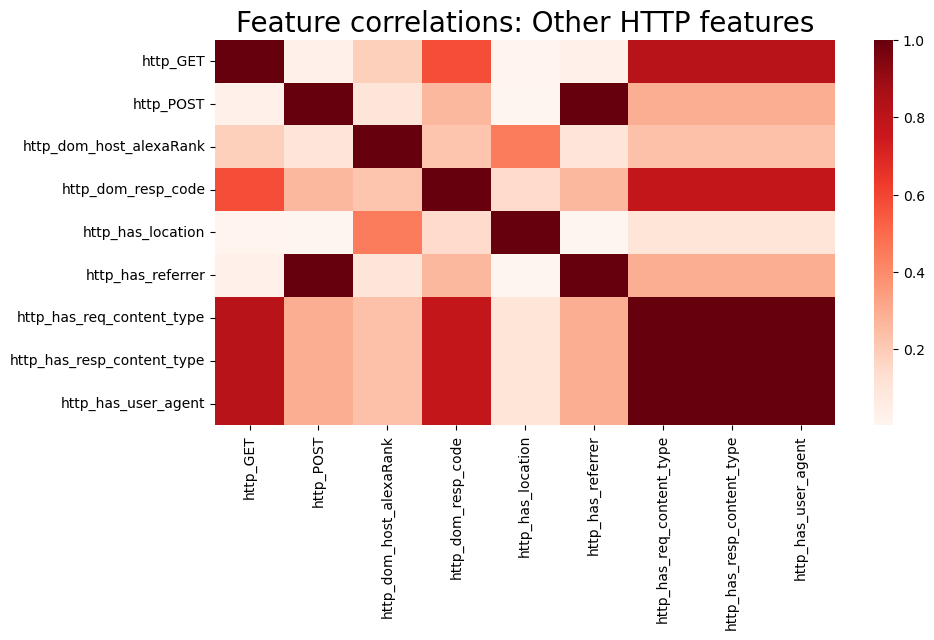

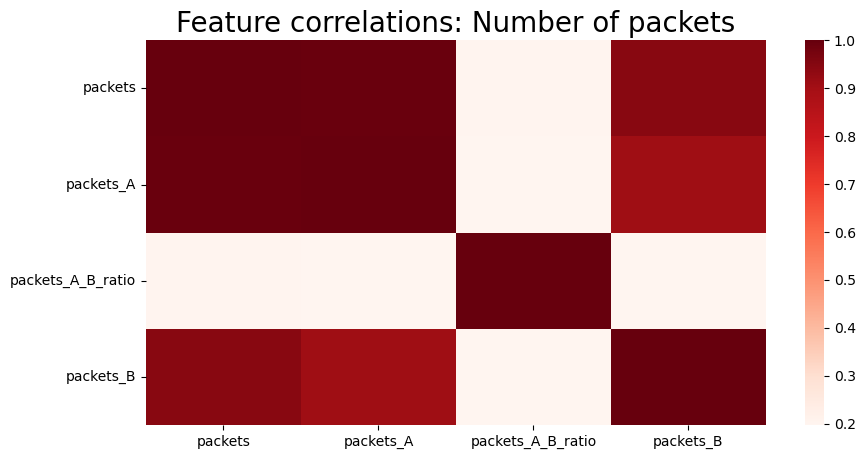

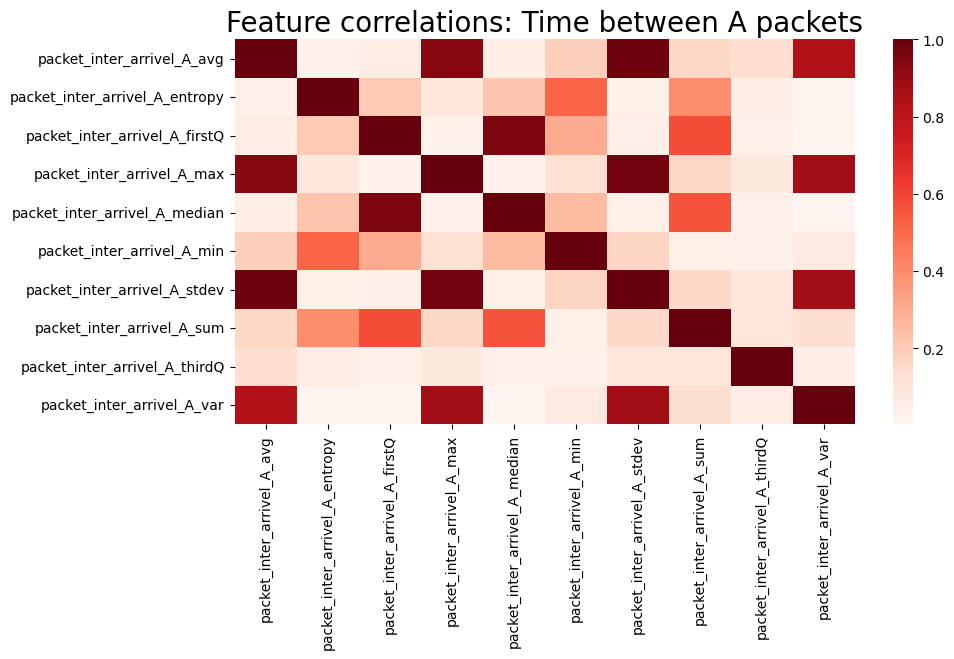

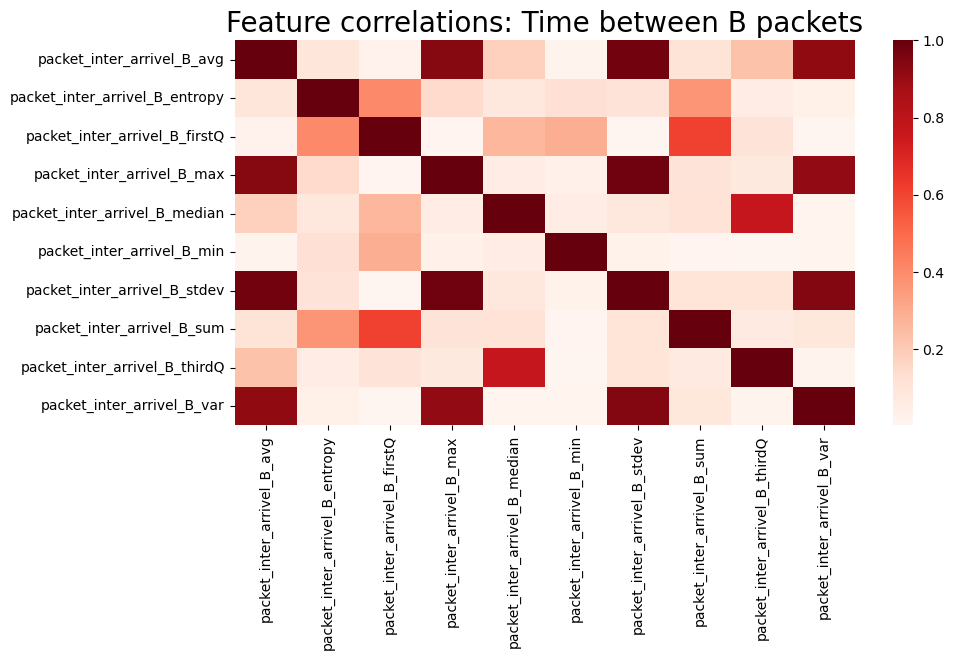

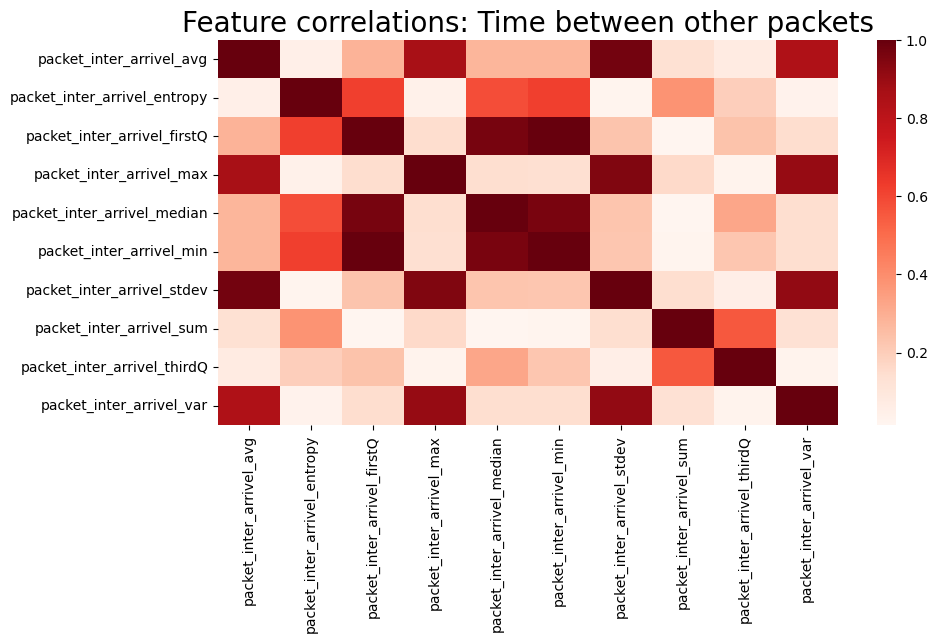

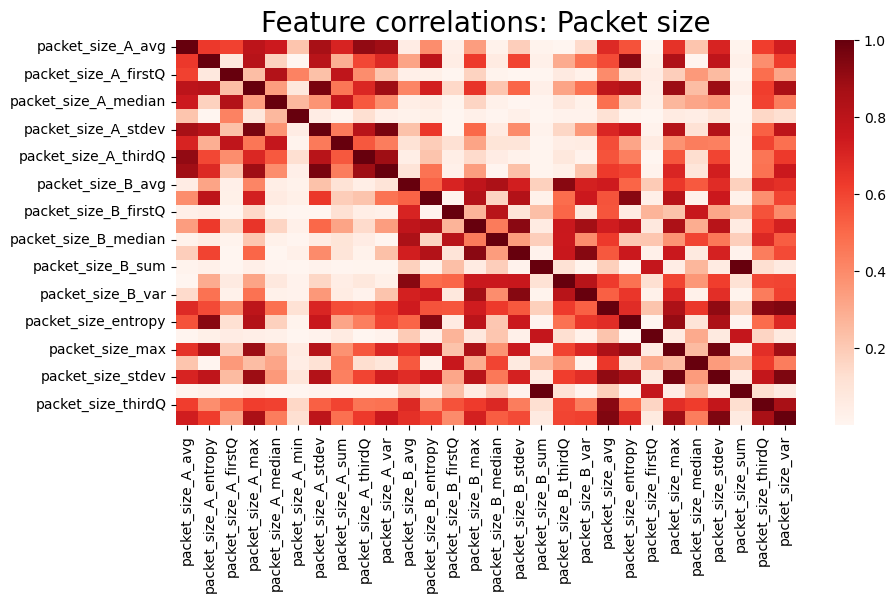

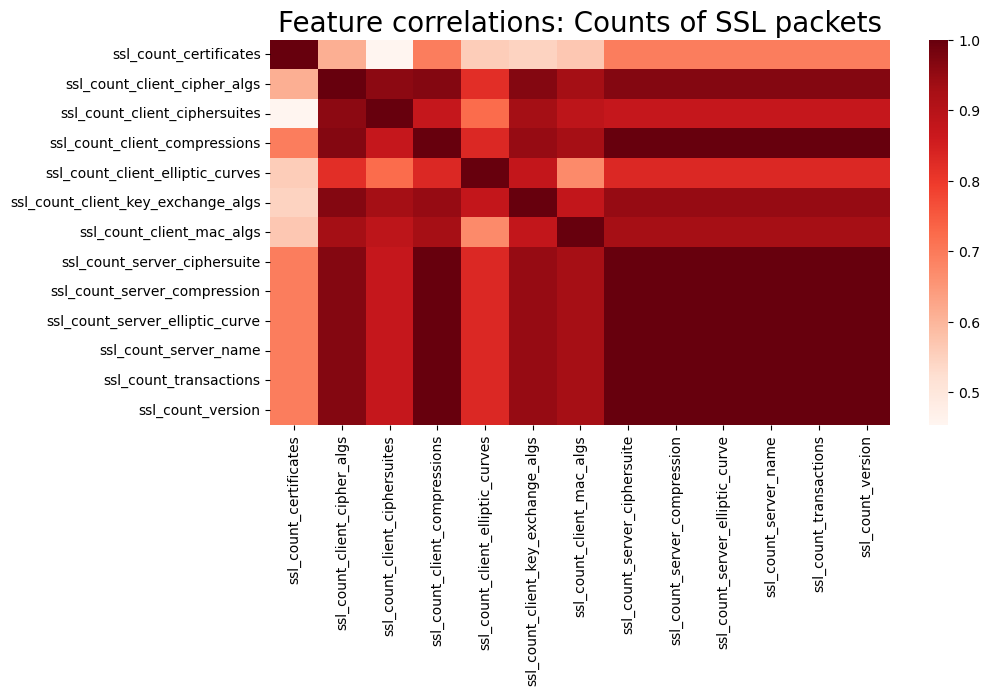

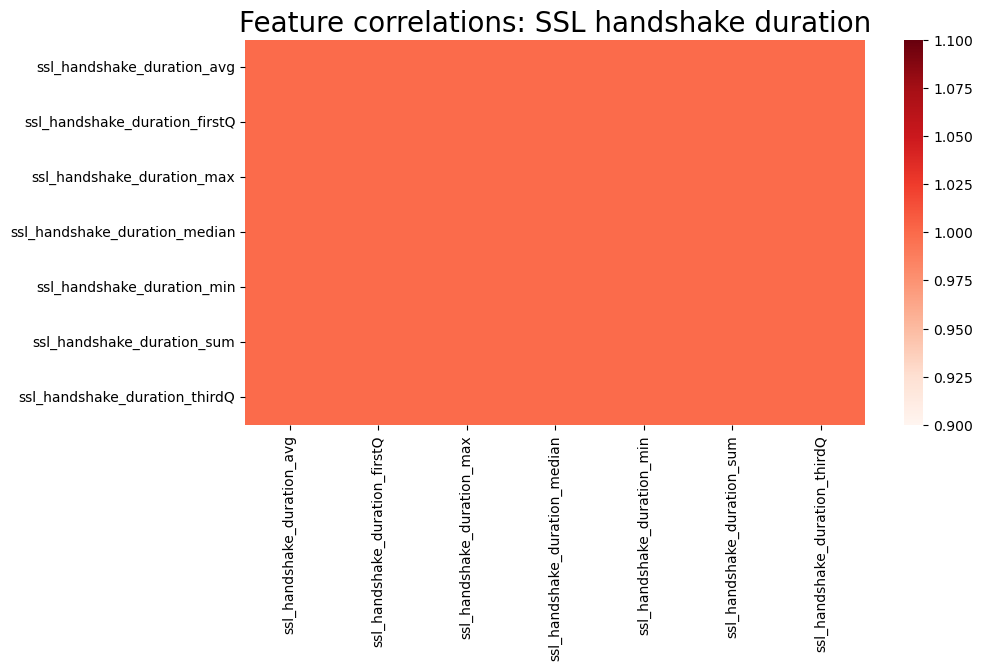

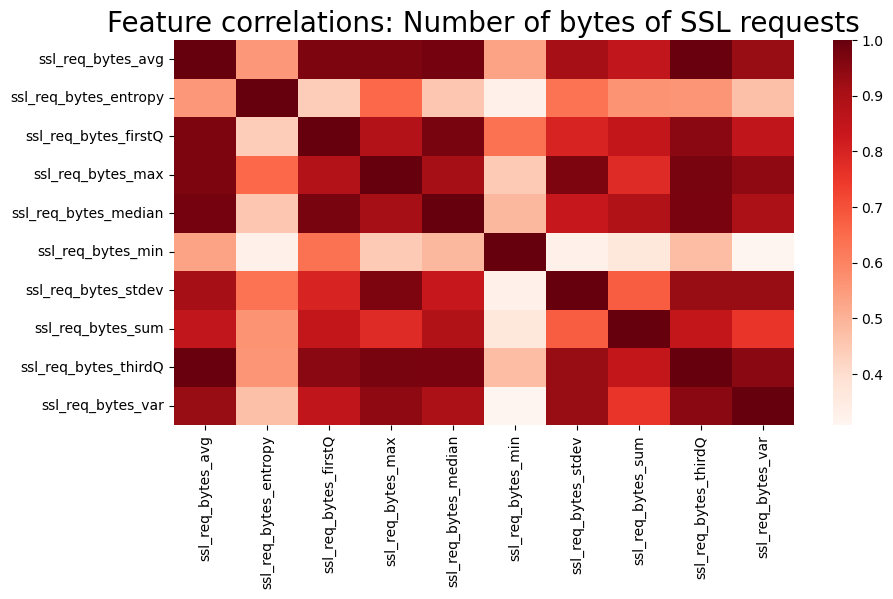

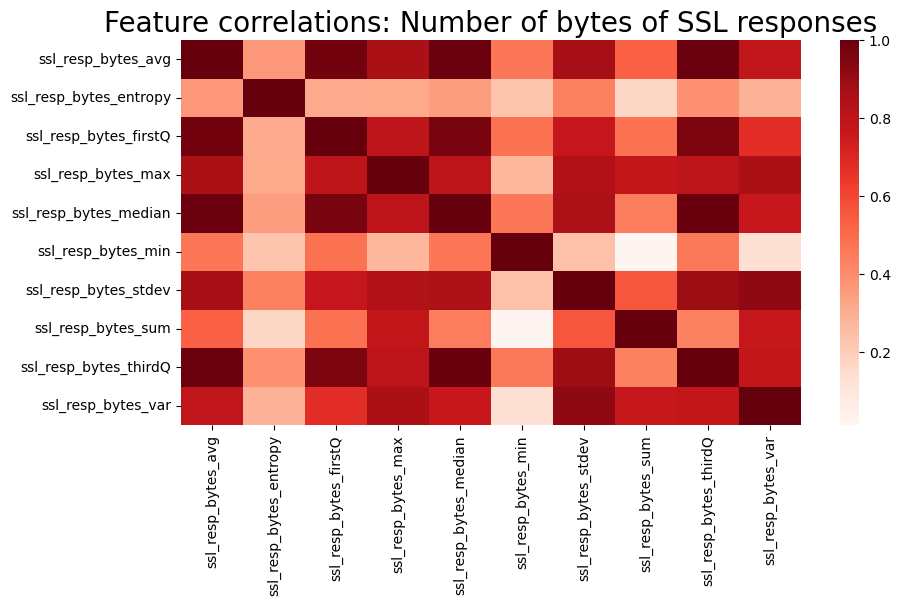

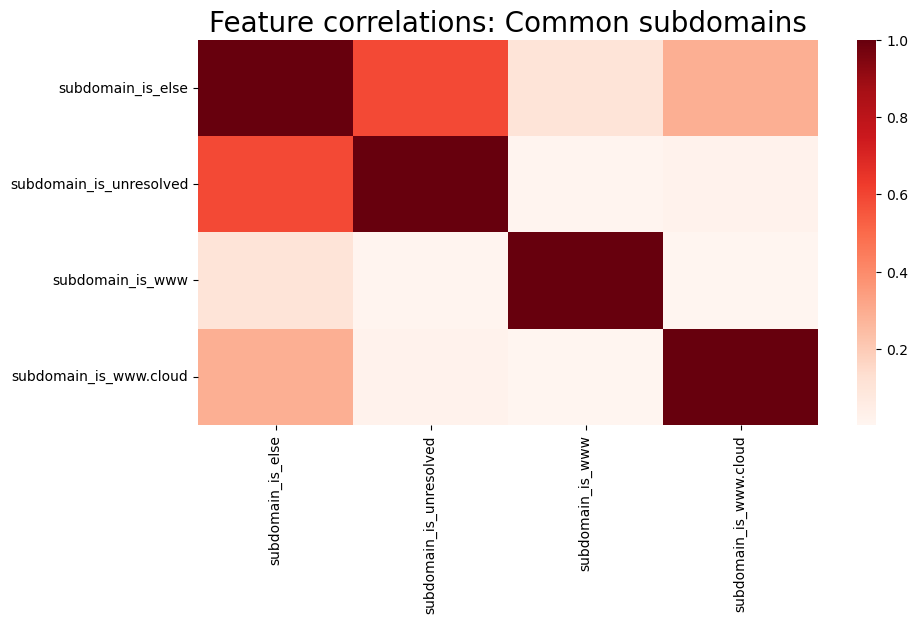

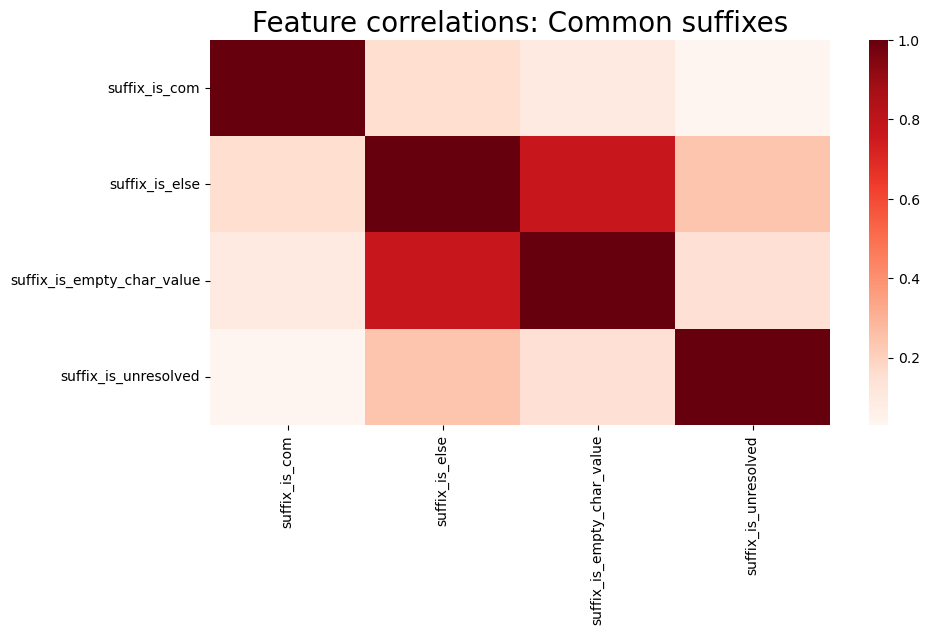

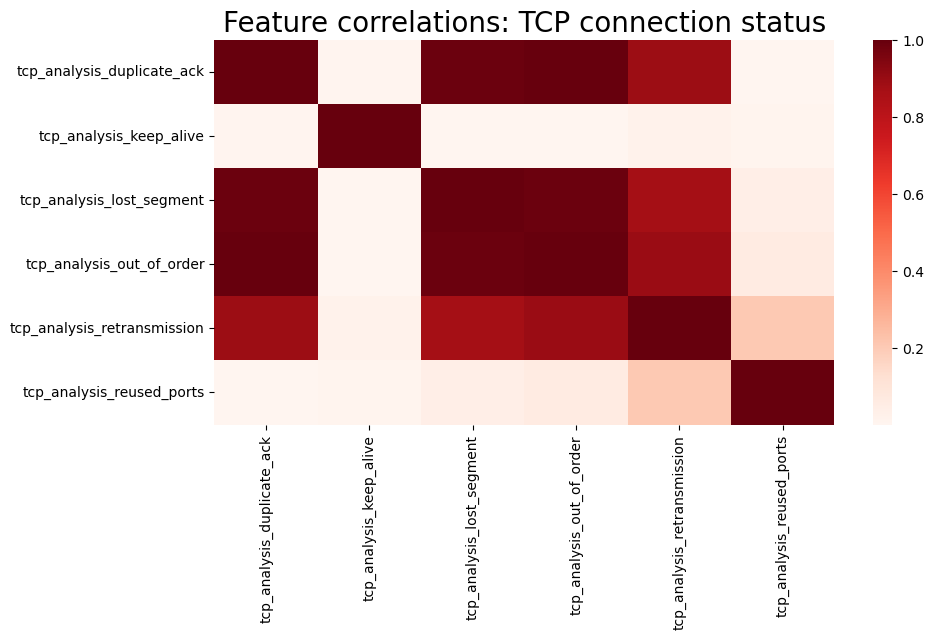

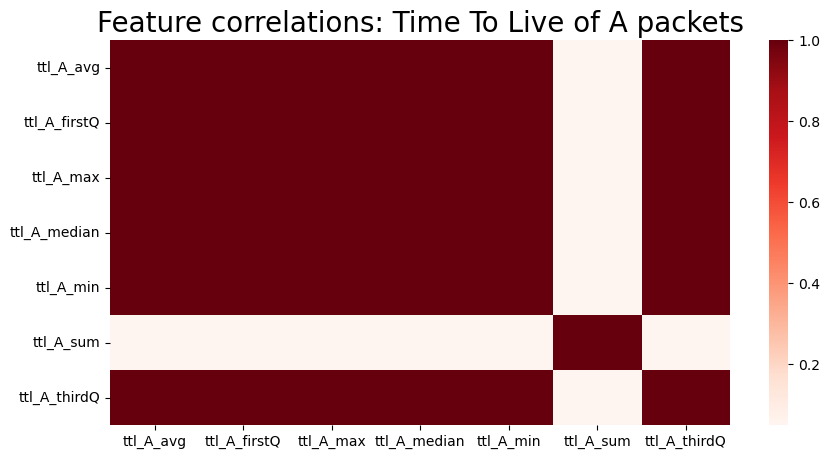

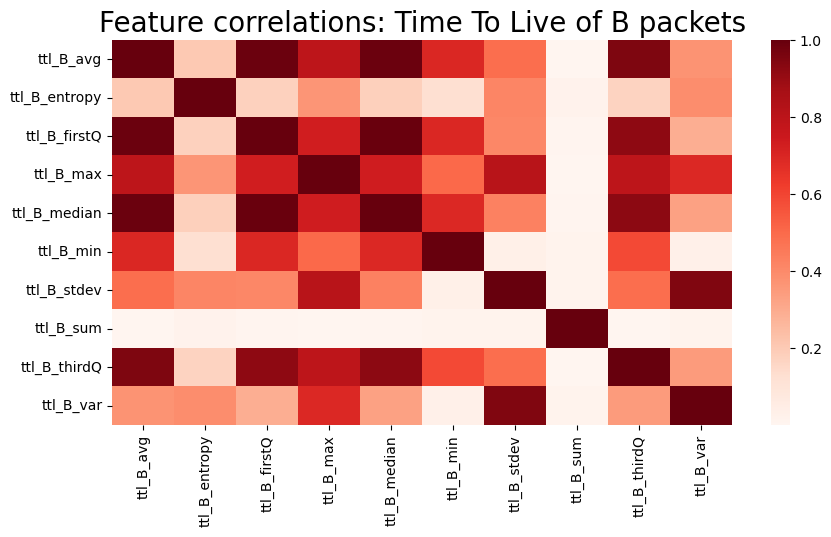

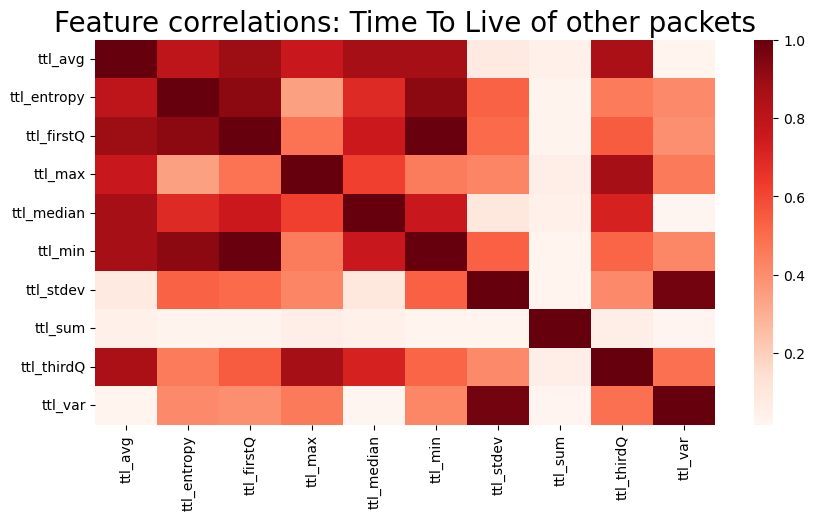

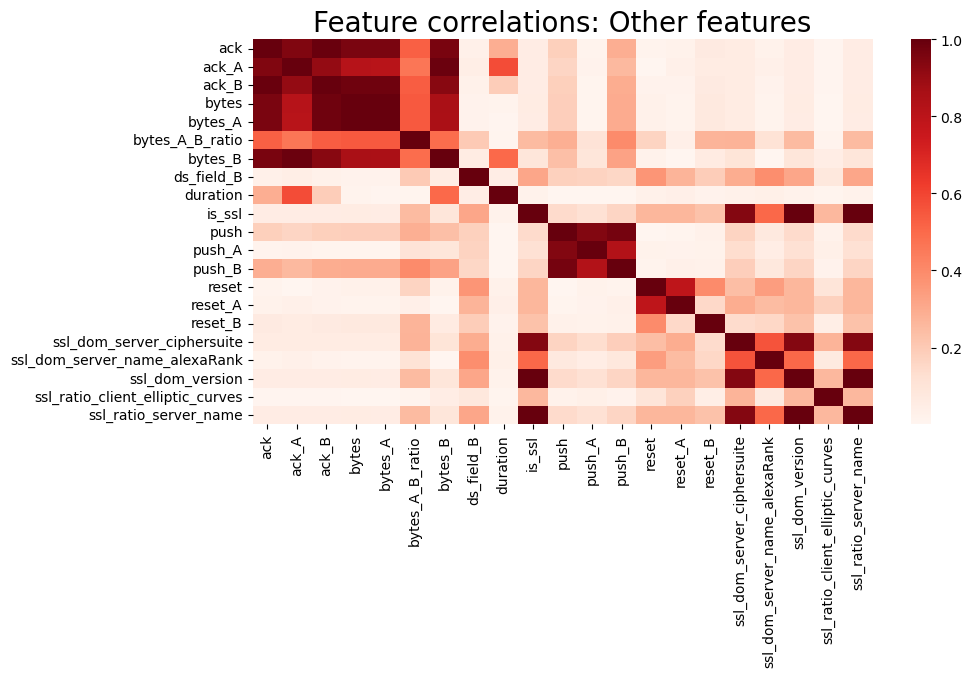

In [310]:
# create a correlation matrix per element of feature_groups
for key in feature_correlations_per_group.keys():
    plt.figure(figsize=(10, 5))
    sns.heatmap(data=feature_correlations_per_group[key], cmap='Reds')
    plt.title(f"Feature correlations: {feature_group_names[key]}", fontsize = 20)
    plt.show()

<h3>Choosing highly correlated features that are not correlated between them</h3>

In [311]:
corr_per_category

[TV                          1.000000
 ttl_B_min                   0.496075
 reset_B                     0.370424
 ttl_A_avg                   0.308538
 ttl_A_firstQ                0.308538
                               ...   
 suffix_is_co.il                  NaN
 suffix_is_com.sg                 NaN
 suffix_is_googleapis.com         NaN
 suffix_is_net                    NaN
 suffix_is_org                    NaN
 Name: TV, Length: 298, dtype: float64,
 baby_monitor                1.000000
 reset_A                     0.660903
 reset                       0.565487
 ttl_B_stdev                 0.517958
 ttl_B_max                   0.482812
                               ...   
 suffix_is_co.il                  NaN
 suffix_is_com.sg                 NaN
 suffix_is_googleapis.com         NaN
 suffix_is_net                    NaN
 suffix_is_org                    NaN
 Name: baby_monitor, Length: 298, dtype: float64,
 lights                         1.000000
 packet_inter_arrivel_min       0

In [364]:
corr_per_category_dic = {}
for i, value in enumerate(corr_per_category):
    corr_per_category_dic[device_categories[i]] = {corr_per_category[i].index[j]: v for j, v in enumerate(value)}
# pop rightmost element of the dictionary (self-correlation)
for key in corr_per_category_dic.keys():
    (k:= next(iter(corr_per_category_dic[key])), corr_per_category_dic[key].pop(k))
print(corr_per_category_dic)

{'TV': {'ttl_B_min': 0.4960747218881487, 'reset_B': 0.37042371106026345, 'ttl_A_avg': 0.30853765772929354, 'ttl_A_firstQ': 0.30853765772929354, 'ttl_A_max': 0.30853765772929354, 'ttl_A_median': 0.30853765772929354, 'ttl_A_min': 0.30853765772929354, 'ttl_A_thirdQ': 0.30853765772929354, 'ttl_B_median': 0.2872173326154597, 'ttl_B_firstQ': 0.27823140599800156, 'ttl_B_avg': 0.27817730276489794, 'http_resp_bytes_min': 0.25903389708872354, 'http_resp_bytes_firstQ': 0.25892346001751787, 'http_resp_bytes_median': 0.2588068148221234, 'http_resp_bytes_avg': 0.2578488334500503, 'http_resp_bytes_thirdQ': 0.2576828696268809, 'http_resp_bytes_max': 0.25181266510234, 'ssl_count_client_mac_algs': 0.24988736005409207, 'http_resp_bytes_sum': 0.24517112276634187, 'reset': 0.24405954778180838, 'packet_inter_arrivel_median': 0.23877127987321423, 'ttl_max': 0.23504670951846823, 'ttl_B_thirdQ': 0.22487800978605685, 'packet_inter_arrivel_A_min': 0.22477634437853602, 'ttl_avg': 0.21976148297511489, 'B_is_system

In [389]:
corr_per_category_top_low_colinearity = {category: {} for category in device_categories}

In [390]:
corr_per_category_top_low_colinearity = {category: {} for category in device_categories}
for category in device_categories:
    currentCategory_topCorrelations_count = 0
    for feature in corr_per_category_dic[category].keys():
        if len(corr_per_category_top_low_colinearity[category]) >= 10: break
        # check if the new feature is highly correlated to another one already selected
        print("current feature", feature)
        currentFeature_isIntercorrelated = False
        for currentCategory_topCorrelations_feature in corr_per_category_top_low_colinearity[category].keys():
            print(feature, currentCategory_topCorrelations_feature)
            print(feature_correlations[feature][currentCategory_topCorrelations_feature])
            if feature_correlations[feature][currentCategory_topCorrelations_feature] > 0.6: 
                print("FEATURE IS TOO CORRELATED TO", currentCategory_topCorrelations_feature)
                currentFeature_isIntercorrelated = True
                break
        # add feature to the list of top correlations if it is not highly correlated to another one already selected for the same category
        if not currentFeature_isIntercorrelated: corr_per_category_top_low_colinearity[category][feature] = corr_per_category_dic[category][feature]
    print("Finished category", category)
    print(corr_per_category_top_low_colinearity[category])

current feature ttl_B_min
current feature reset_B
reset_B ttl_B_min
0.4534364591930147
current feature ttl_A_avg
ttl_A_avg ttl_B_min
0.46324057136091384
ttl_A_avg reset_B
0.2749278900624026
current feature ttl_A_firstQ
ttl_A_firstQ ttl_B_min
0.46324057136091384
ttl_A_firstQ reset_B
0.2749278900624026
ttl_A_firstQ ttl_A_avg
1.0
FEATURE IS TOO CORRELATED TO ttl_A_avg
current feature ttl_A_max
ttl_A_max ttl_B_min
0.46324057136091384
ttl_A_max reset_B
0.2749278900624026
ttl_A_max ttl_A_avg
1.0
FEATURE IS TOO CORRELATED TO ttl_A_avg
current feature ttl_A_median
ttl_A_median ttl_B_min
0.46324057136091384
ttl_A_median reset_B
0.2749278900624026
ttl_A_median ttl_A_avg
1.0
FEATURE IS TOO CORRELATED TO ttl_A_avg
current feature ttl_A_min
ttl_A_min ttl_B_min
0.46324057136091384
ttl_A_min reset_B
0.2749278900624026
ttl_A_min ttl_A_avg
1.0
FEATURE IS TOO CORRELATED TO ttl_A_avg
current feature ttl_A_thirdQ
ttl_A_thirdQ ttl_B_min
0.46324057136091384
ttl_A_thirdQ reset_B
0.2749278900624026
ttl_A_thir

In [397]:
print(corr_per_category_top_dict)

{'TV': ttl_B_min       0.496075
reset_B         0.370424
ttl_A_avg       0.308538
ttl_A_firstQ    0.308538
ttl_A_max       0.308538
ttl_A_median    0.308538
ttl_A_min       0.308538
ttl_A_thirdQ    0.308538
ttl_B_median    0.287217
ttl_B_firstQ    0.278231
Name: TV, dtype: float64, 'baby_monitor': reset_A                  0.660903
reset                    0.565487
ttl_B_stdev              0.517958
ttl_B_max                0.482812
ttl_B_thirdQ             0.469859
ttl_B_avg                0.434098
ttl_B_firstQ             0.424674
ttl_B_median             0.421507
packet_size_B_entropy    0.404990
ttl_B_var                0.393354
Name: baby_monitor, dtype: float64, 'lights': packet_inter_arrivel_min       0.581965
B_port_is_8080                 0.577076
packet_inter_arrivel_firstQ    0.575378
ttl_min                        0.574552
ttl_firstQ                     0.573342
ds_field_B                     0.572415
packet_inter_arrivel_A_min     0.561040
packet_inter_arrivel_median    0.55

In [414]:
# create a correlation matrix per element of feature_groups
correlation_lowColinearityFeatures = {
    device_category: pd.DataFrame() for device_category in device_categories
}
correlation_highColinearityFeatures = {
    device_category: pd.DataFrame() for device_category in device_categories
}
for device_category in corr_per_category_top_low_colinearity.keys():
    currentCategory_lowColinearityFeatures = list(corr_per_category_top_low_colinearity[key].keys())
    currentCategory_highColinearityFeatures = []
    for feature in corr_per_category_dic[device_category].keys():
            if len(currentCategory_highColinearityFeatures) < 10: currentCategory_highColinearityFeatures.append(feature)
            else: break
    tempdf_lowColinearity = pd.DataFrame(index=currentCategory_lowColinearityFeatures, columns=currentCategory_lowColinearityFeatures)
    tempdf_highColinearity = pd.DataFrame(index=currentCategory_highColinearityFeatures, columns=currentCategory_highColinearityFeatures)
    for row in feature_correlations.iterrows():
        if row[0] in currentCategory_lowColinearityFeatures:
            tempdf_lowColinearity[row[0]] = tempdf_lowColinearity.index.map(lambda x: feature_correlations.loc[x, row[0]])
        if row[0] in currentCategory_highColinearityFeatures:
            tempdf_highColinearity[row[0]] = tempdf_highColinearity.index.map(lambda x: feature_correlations.loc[x, row[0]])
    correlation_lowColinearityFeatures[device_category] = tempdf_lowColinearity.dropna(axis=0, how='all').dropna(axis=1, how='all')
    correlation_highColinearityFeatures[device_category] = tempdf_highColinearity.dropna(axis=0, how='all').dropna(axis=1, how='all')

In [393]:
device_category_names = {
    'TV': 'TV',
    'baby_monitor': 'Baby monitor',
    'lights': 'Lights',
    'motion_sensor': 'Motion sensor',
    'security_camera': 'Security camera',
    'smoke_detector': 'Smoke detector',
    'socket': 'Socket',
    'thermostat': 'Thermostat',
    'watch': 'Watch',
    'water_sensor': 'Water sensor'
}

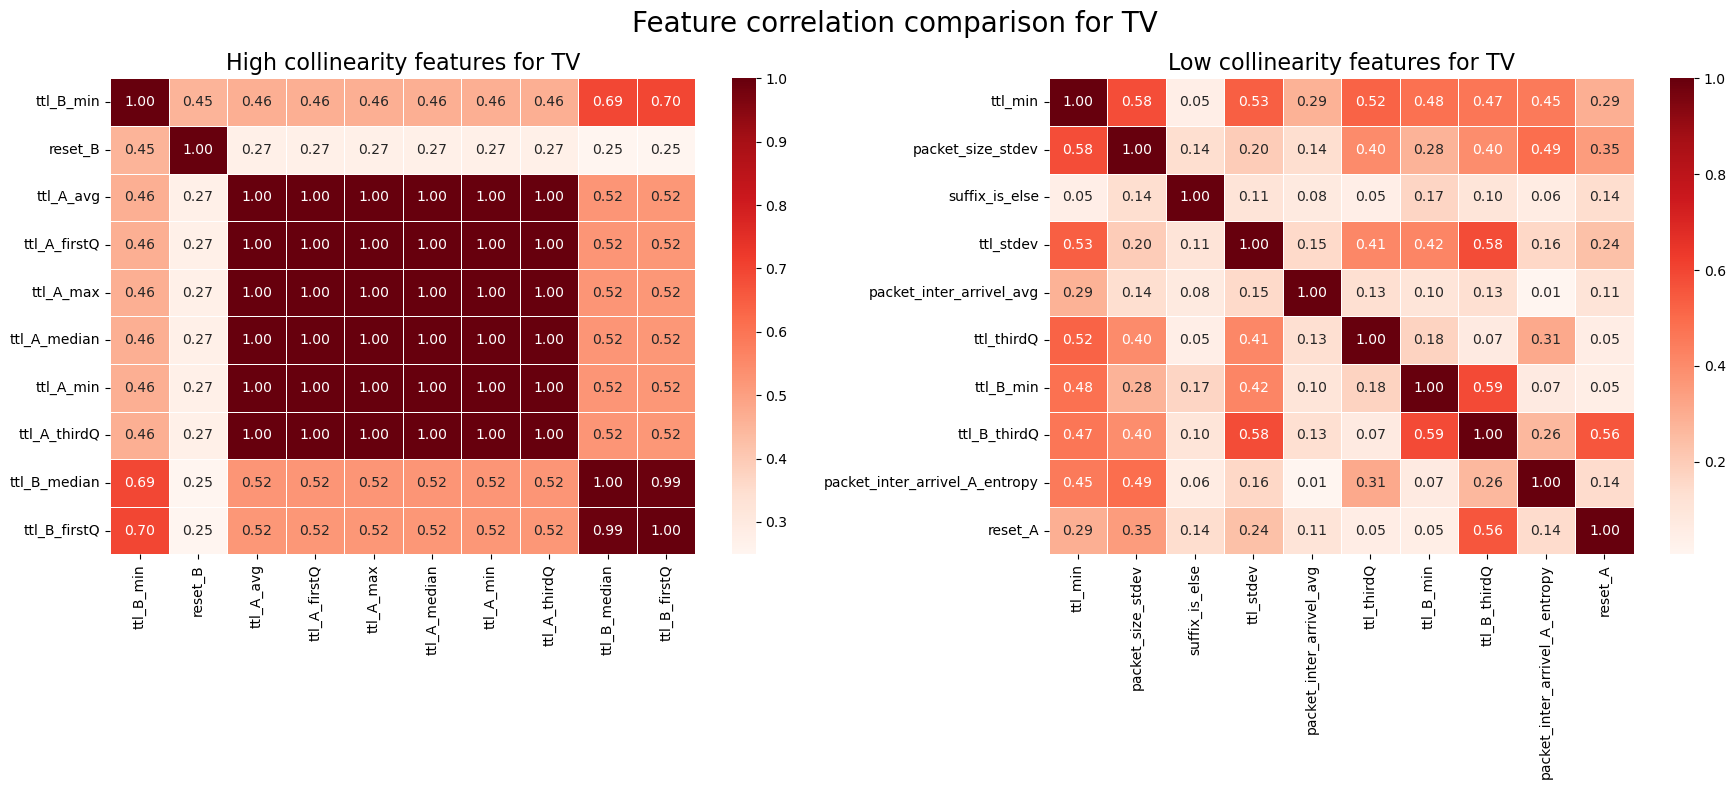

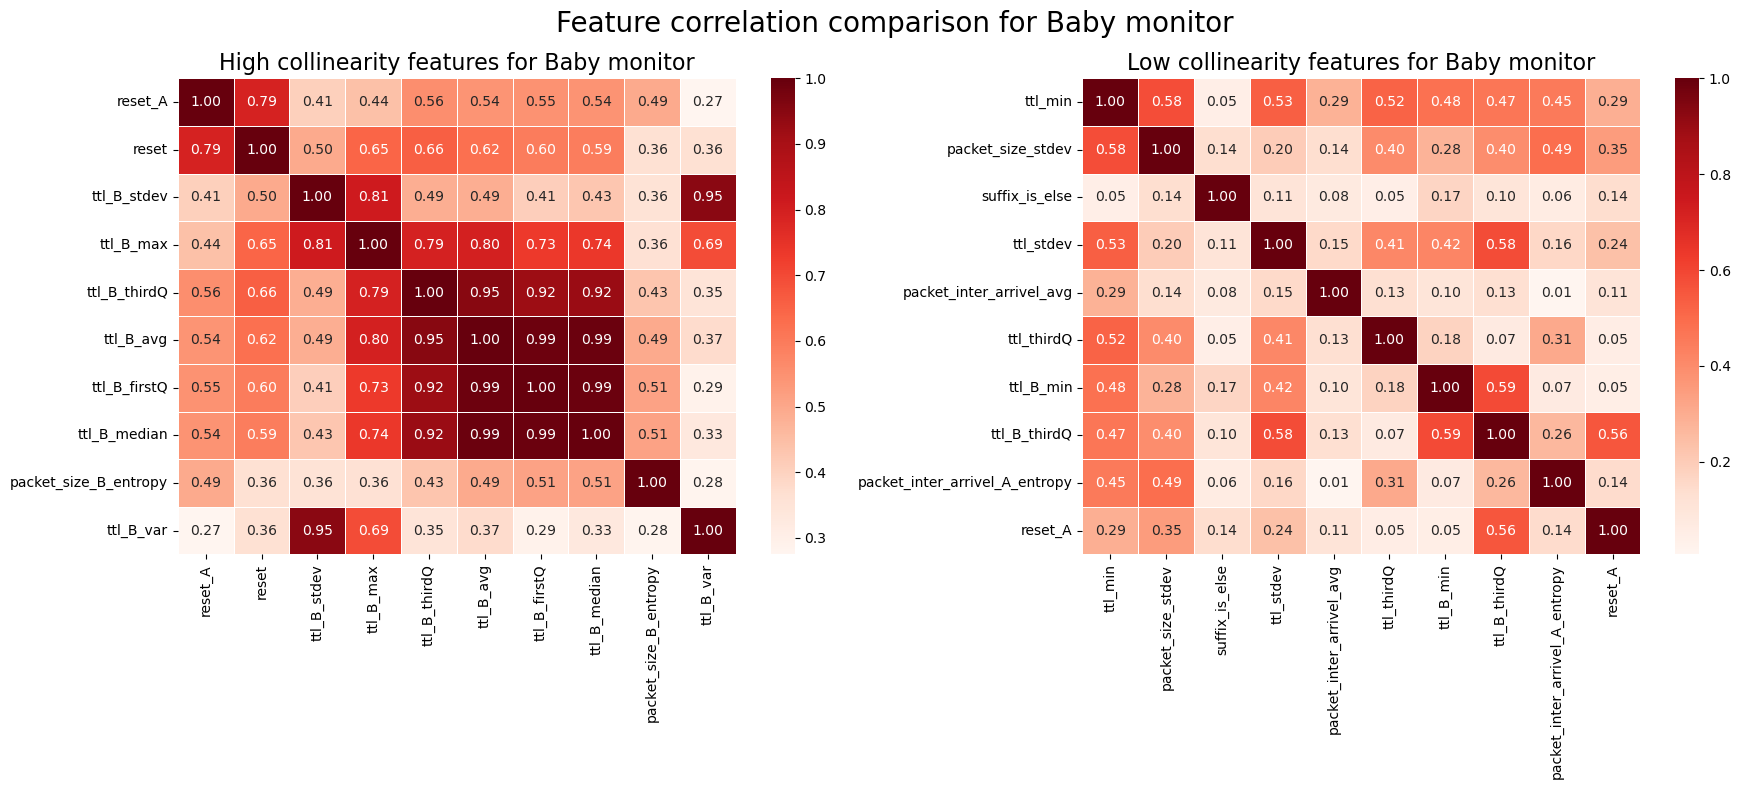

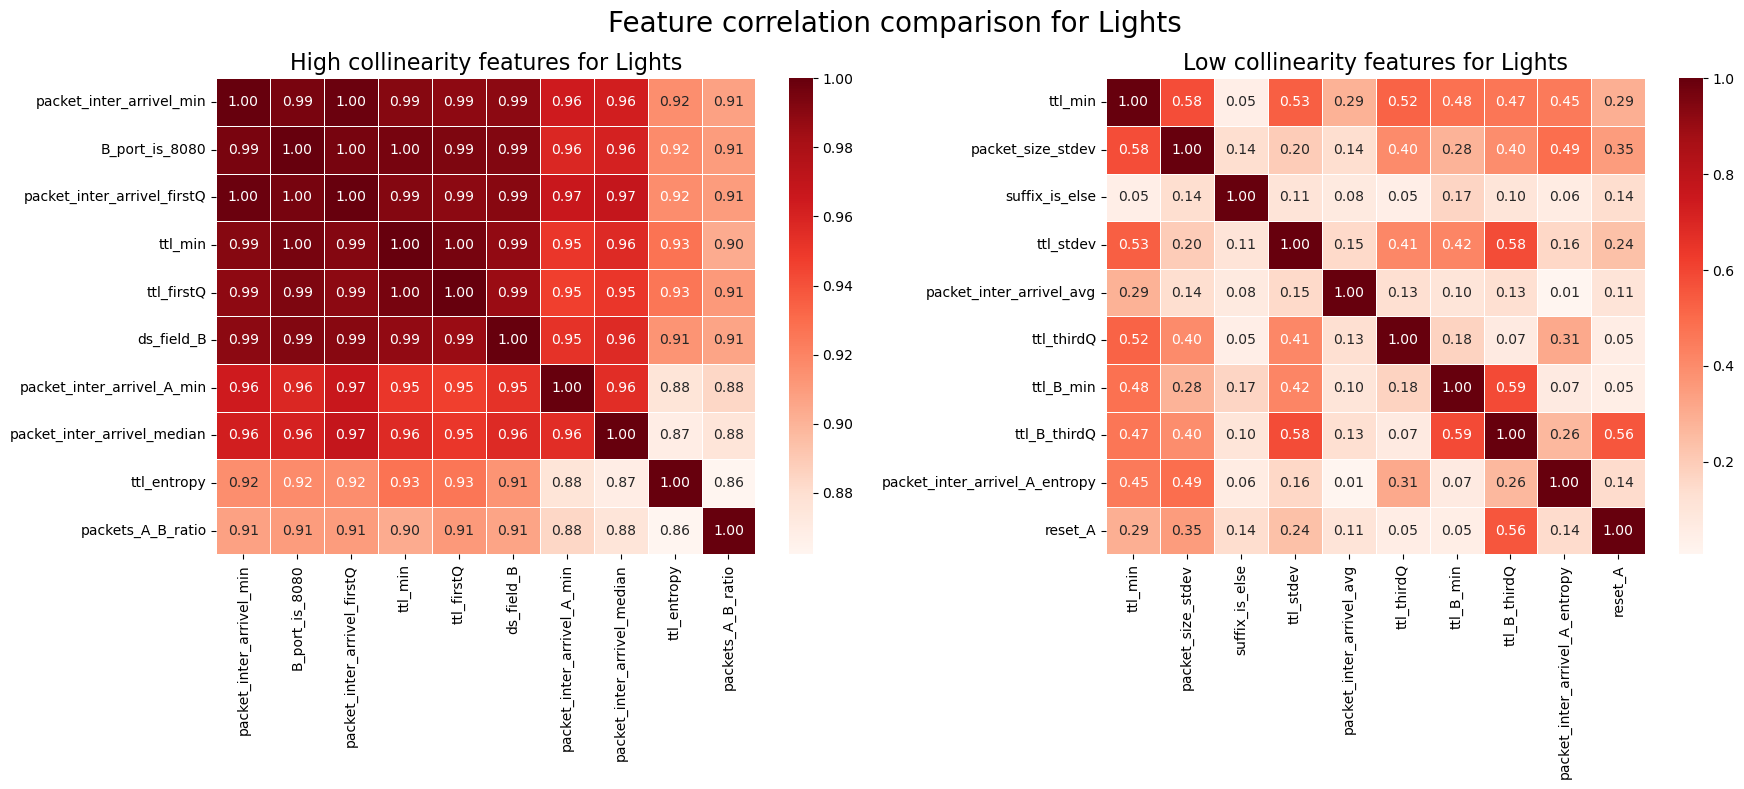

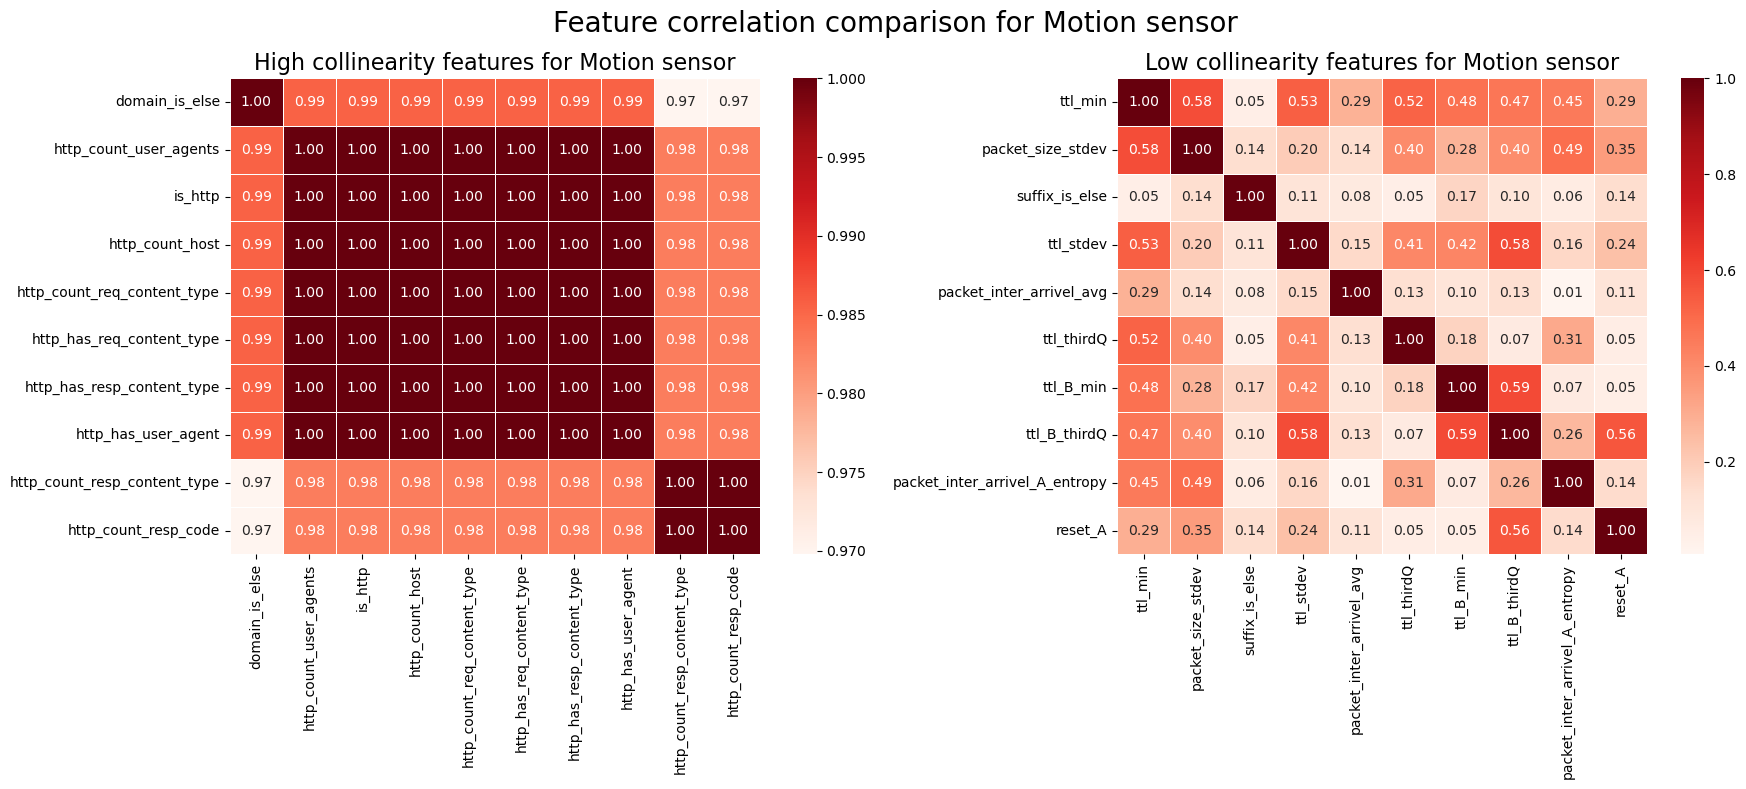

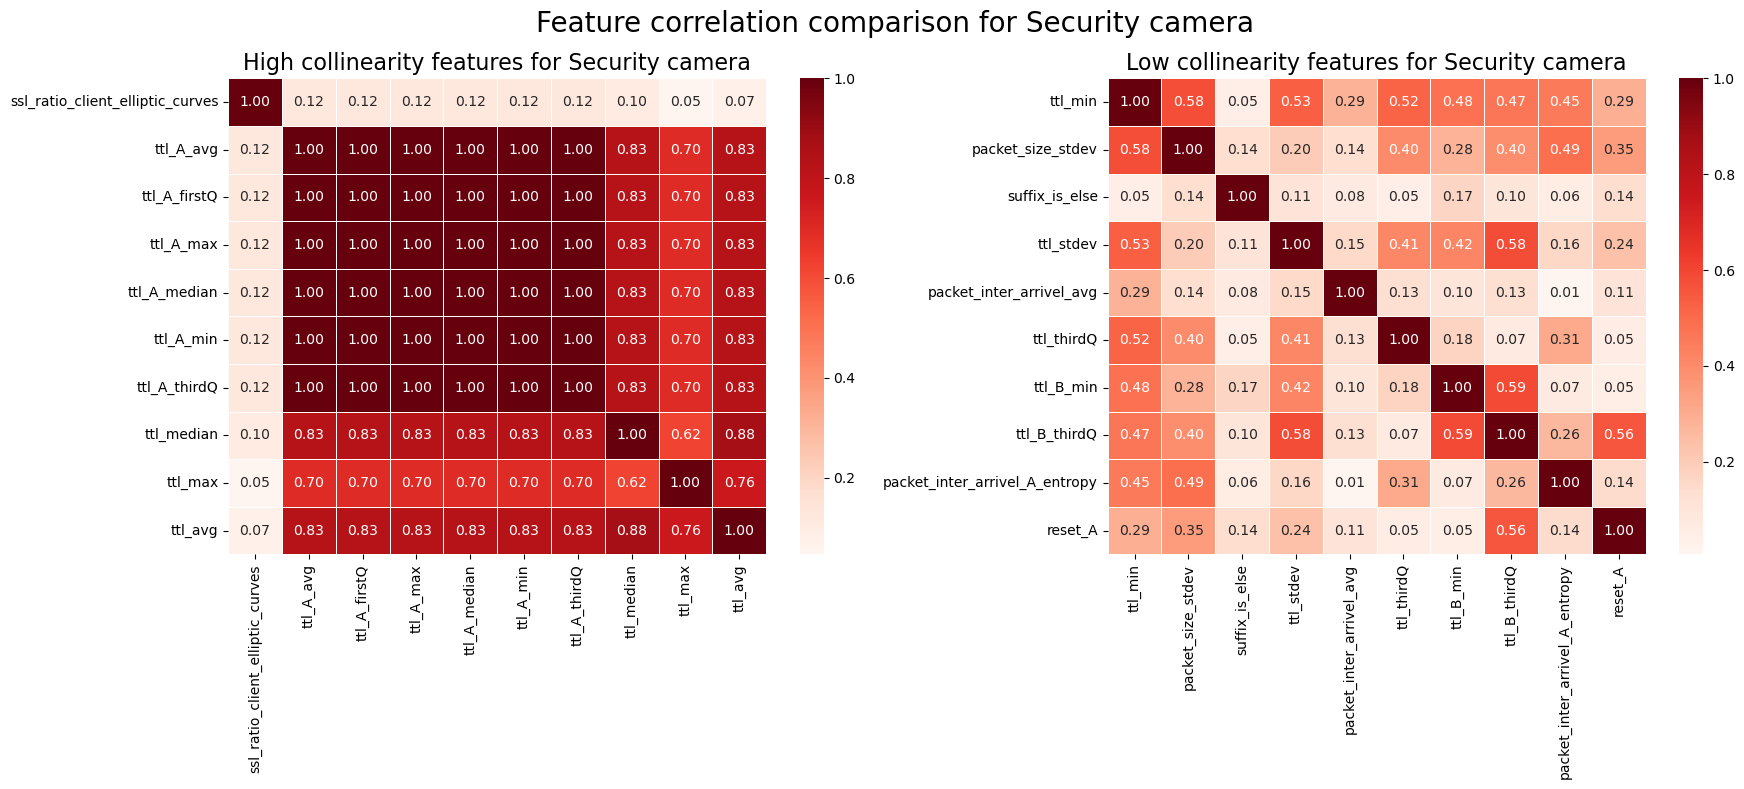

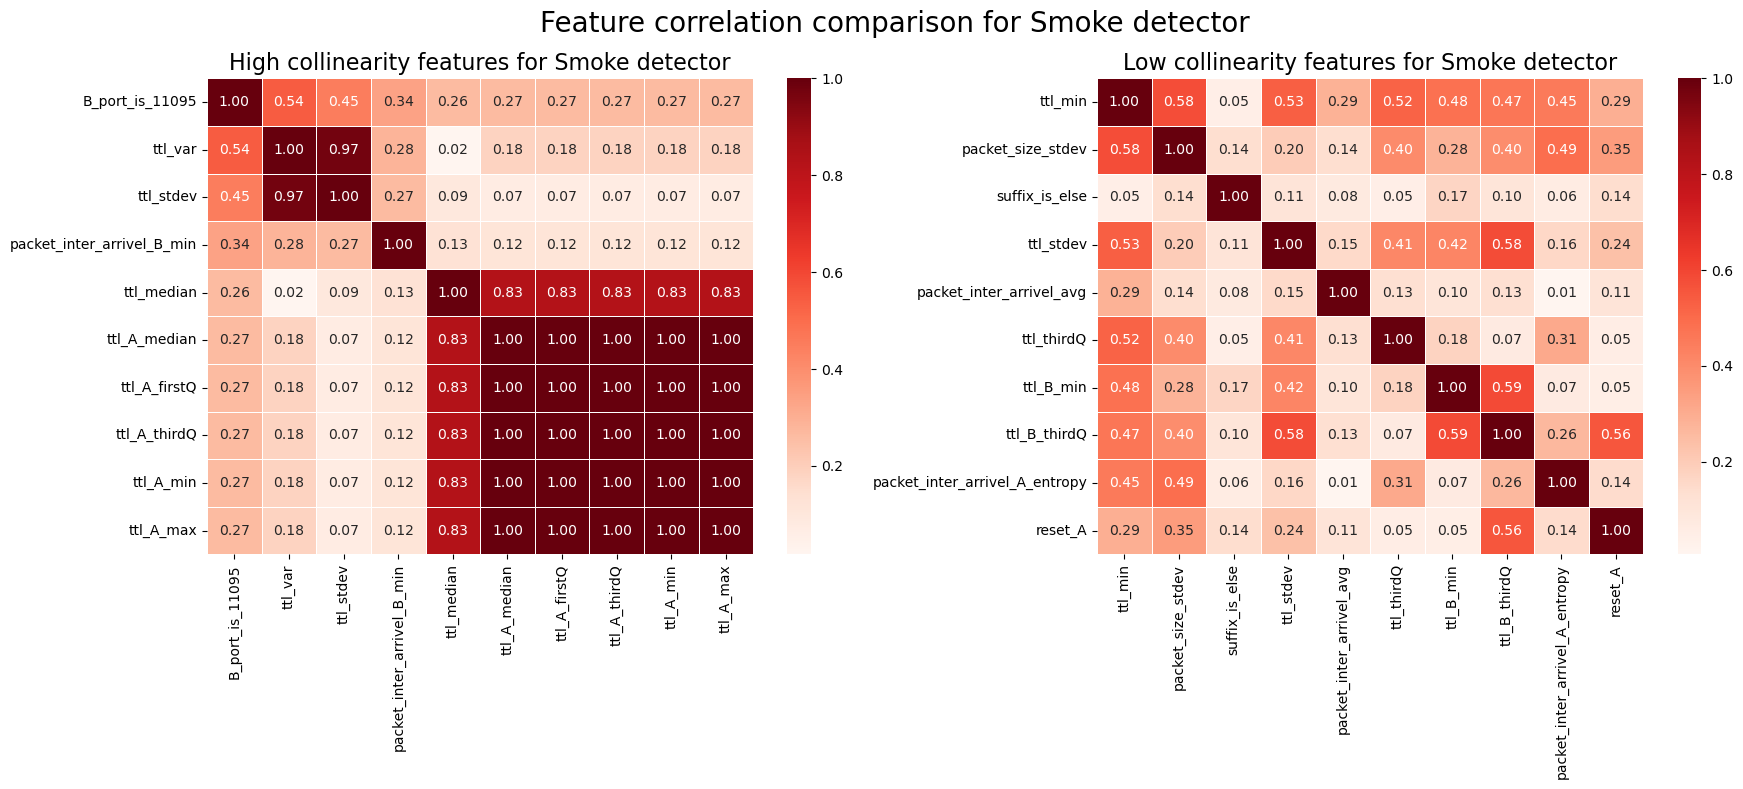

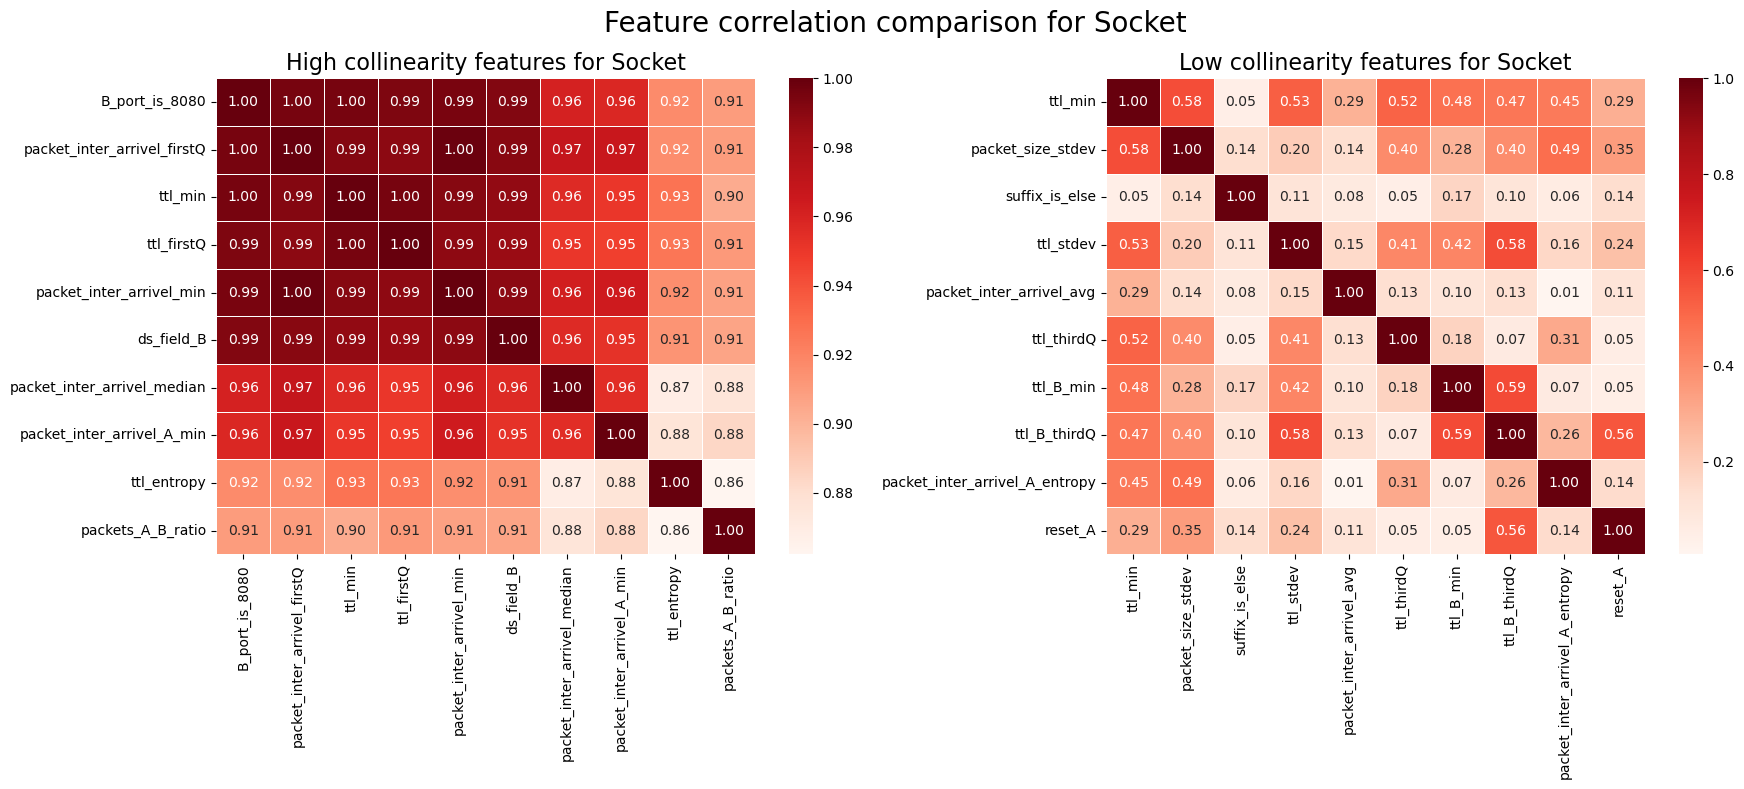

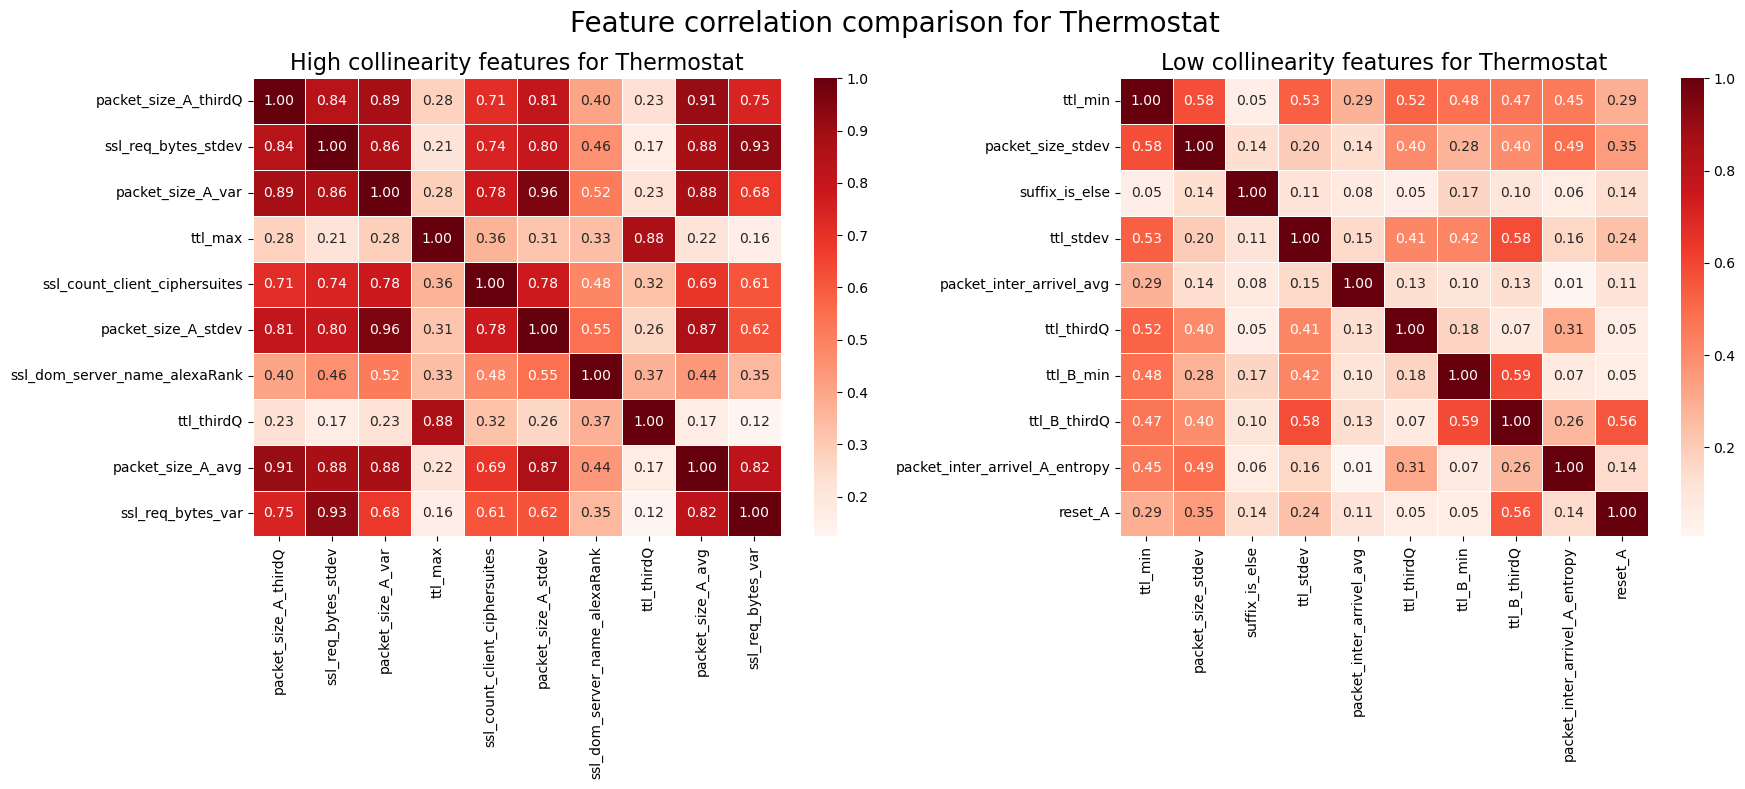

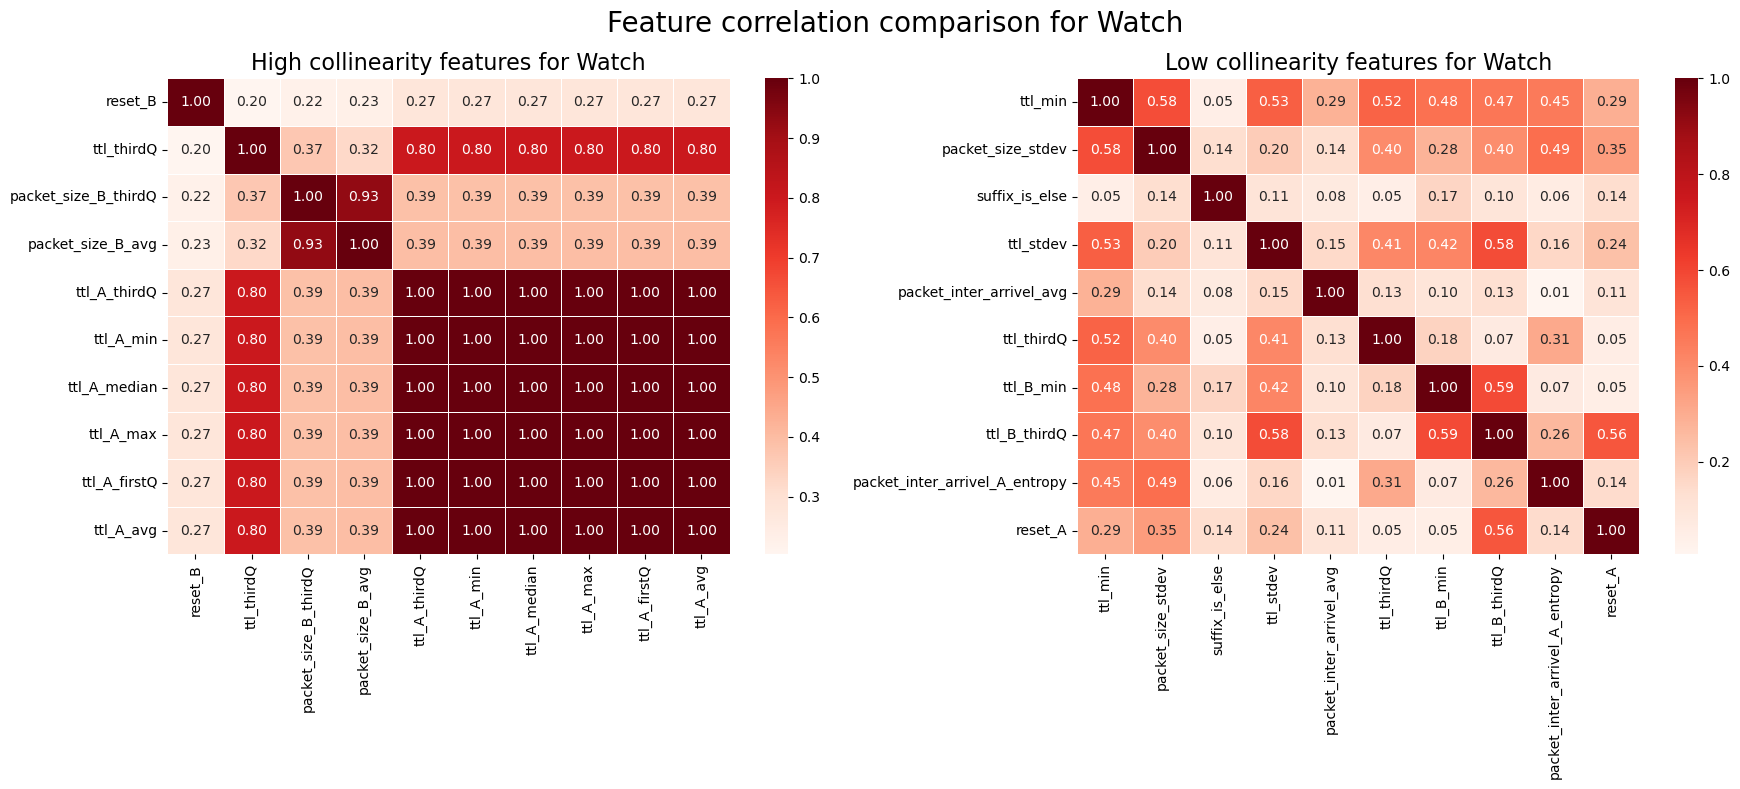

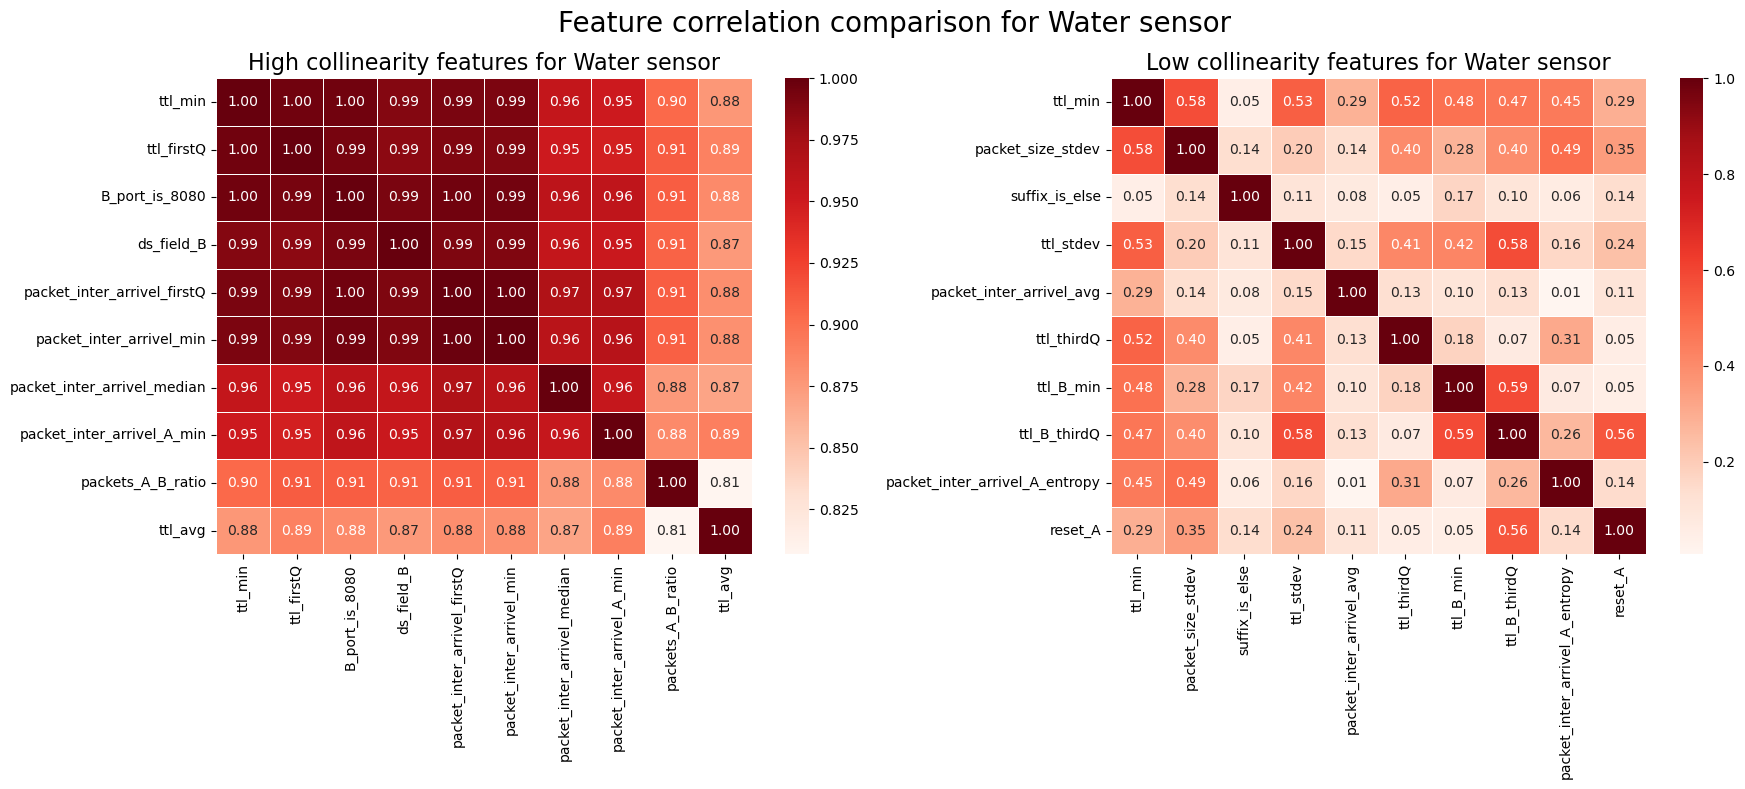

In [415]:
# Create a figure with 2 columns of heatmaps (high collinearity vs low collinearity) for each device category
for device_category in correlation_lowColinearityFeatures.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # Left plot: Highly correlated features
    if device_category in correlation_highColinearityFeatures:
        sns.heatmap(data=correlation_highColinearityFeatures[device_category], 
                   cmap='Reds', ax=ax1, annot=True, fmt=".2f", linewidths=.5)
        ax1.set_title(f"High collinearity features for {device_category_names[device_category]}", fontsize=16)
    
    # Right plot: Low collinearity features
    if device_category in correlation_lowColinearityFeatures:
        sns.heatmap(data=correlation_lowColinearityFeatures[device_category], 
                   cmap='Reds', ax=ax2, annot=True, fmt=".2f", linewidths=.5)
        ax2.set_title(f"Low collinearity features for {device_category_names[device_category]}", fontsize=16)
    
    plt.suptitle(f"Feature correlation comparison for {device_category_names[device_category]}", fontsize=20)
    plt.tight_layout()
    plt.show()

In [ ]:
# print highly-colinear features for each device category for comparison


In [ ]:
# Get all unique feature names across all categories
selected_features_low_colinearity = set()
for i in range(len(device_categories)):
    top_corr = corr_per_category_top[i]
    if device_categories[i] in top_corr.index:
        top_corr = top_corr.drop(device_categories[i])
    features.update(top_corr.index)
features = list(features)
# order elements of all_features alphabetically
features.sort()
print(features)
print(len(features))